# Lake Taney mooring monitoring notebook

This notebook is organized so that a new mooring campaign can be added, processed, analysed, and exported with minimal changes.

Main workflow:

1. Packages and helper functions
2. Data inputs and loading
3. Data processing into common analysis arrays
4. Analysis and plotting, with assumptions kept close to the relevant analysis
5. Export of useful figures and summary tables

## How future campaigns should be added

Add a new mooring campaign only in the settings cell below after the raw logger data have been converted to Level3 NetCDF files.

Expected HOBO folder pattern:

`../data/Mooring/HOBO_T/YYYYMMDD/Level3/`

Optional miniDOT data should be placed in:

`../data/Mooring/miniDOT/YYYYMMDD/Level2/`

Optional meteorological forcing files should be placed in:

`../data/Meteo/`

Keep raw data cleaning decisions, such as retrieval cutoffs, explicit in the notebook. Do not silently delete raw points.

## 1. Packages and general settings

In [1]:
import os
import copy
import numpy as np
import pandas as pd
import netCDF4
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime
from scipy.interpolate import interp1d

try:
    import cmocean
    cmap_temperature = cmocean.cm.thermal
except Exception:
    cmap_temperature = "plasma"

# Uncomment this in JupyterLab if you want interactive figures and ipympl is installed.
# %matplotlib widget


## 1.1 Helper functions

In [2]:
def masked_to_nan(x):
    """Convert masked arrays to regular float arrays with NaN."""
    x = np.asanyarray(x)

    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)

    return np.asarray(x, dtype=float)


def decode_netcdf_time(time_var):
    """Decode a NetCDF time variable to Unix seconds and Python datetimes."""
    time_raw = np.asanyarray(time_var[:])

    if np.ma.isMaskedArray(time_raw):
        time_raw = time_raw.filled(np.nan)

    if hasattr(time_var, "units"):
        try:
            time_dates = netCDF4.num2date(
                time_raw,
                units=time_var.units,
                calendar=getattr(time_var, "calendar", "standard"),
                only_use_cftime_datetimes=False
            )

            time_dates = np.array([
                datetime(t.year, t.month, t.day, t.hour, t.minute, t.second)
                for t in time_dates
            ])

            time_num = np.array([
                np.datetime64(t, "s").astype("int64")
                for t in time_dates
            ], dtype=float)

            return time_num, time_dates

        except Exception as e:
            print("num2date failed, trying Unix seconds:", e)

    time_num = time_raw.astype(float)
    time_dates = time_num.astype("datetime64[s]").astype(datetime)

    return time_num, time_dates


def read_l3_file(filepath):
    """Read one HOBO Level3 file and return time, depth, temp in depth x time format."""
    with netCDF4.Dataset(filepath) as nc:
        time_var = nc.variables["time"]
        time_num, time_date = decode_netcdf_time(time_var)

        depth = masked_to_nan(nc.variables["depth"][:])
        temp = masked_to_nan(nc.variables["temp"][:])

        n_depth = len(depth)
        n_time = len(time_num)

        if temp.shape == (n_time, n_depth):
            temp = temp.T
        elif temp.shape != (n_depth, n_time):
            raise ValueError(
                "Unexpected temp shape {} in {}. Expected {} or {}.".format(
                    temp.shape,
                    filepath,
                    (n_depth, n_time),
                    (n_time, n_depth)
                )
            )

    return time_num, time_date, depth, temp


def interpolate_profile_to_grid(depth, temp, depth_grid):
    """Interpolate a depth x time temperature matrix to a new depth grid."""
    order = np.argsort(depth)
    depth_sorted = depth[order]
    temp_sorted = temp[order, :]

    f = interp1d(
        depth_sorted,
        temp_sorted,
        axis=0,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    return f(depth_grid)


def interp_with_nans(x_old, y_old, x_new):
    """1D interpolation that ignores NaN values and avoids extrapolation."""
    x_old = np.asarray(x_old, dtype=float)
    y_old = np.asarray(y_old, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    valid = np.isfinite(x_old) & np.isfinite(y_old)
    y_new = np.full(len(x_new), np.nan)

    if np.sum(valid) < 2:
        return y_new

    x_valid = x_old[valid]
    y_valid = y_old[valid]

    order = np.argsort(x_valid)
    x_valid = x_valid[order]
    y_valid = y_valid[order]

    inside = (x_new >= x_valid[0]) & (x_new <= x_valid[-1])

    y_new[inside] = np.interp(
        x_new[inside],
        x_valid,
        y_valid
    )

    return y_new


def water_density(T_C):
    """Freshwater density in kg m-3 from temperature in degrees Celsius."""
    return (
        999.842594
        + 6.793952e-2 * T_C
        - 9.095290e-3 * T_C**2
        + 1.001685e-4 * T_C**3
        - 1.120083e-6 * T_C**4
        + 6.536332e-9 * T_C**5
    )


def find_continuous_runs(mask, time_num, max_gap_factor=3):
    """Find continuous True runs, resetting when there are large time gaps."""
    mask = np.asarray(mask, dtype=bool)
    dt_sec = np.median(np.diff(time_num))

    runs = []
    current_start = None
    current_len = 0

    for kt in range(len(mask)):
        if kt > 0:
            gap_too_large = (time_num[kt] - time_num[kt - 1]) > max_gap_factor * dt_sec
        else:
            gap_too_large = False

        if gap_too_large:
            if current_start is not None:
                runs.append((current_start, kt - 1, current_len))

            current_start = None
            current_len = 0

        if mask[kt]:
            if current_start is None:
                current_start = kt

            current_len += 1

        else:
            if current_start is not None:
                runs.append((current_start, kt - 1, current_len))

            current_start = None
            current_len = 0

    if current_start is not None:
        runs.append((current_start, len(mask) - 1, current_len))

    return runs


## 2. Data inputs

In [3]:
# Main data folders.
# These paths are relative to the notebook location.
data_folder_hobo = os.path.join("..", "data", "Mooring", "HOBO_T")
data_folder_minidot = os.path.join("..", "data", "Mooring", "miniDOT")
data_folder_meteo = os.path.join("..", "data", "Meteo", "Additional")

# Root data folder (parent of Mooring/, Meteo/)
data_folder = os.path.join("..", "data")

# Campaign folders to include in the long-term analysis.
# To add a future campaign:
#   1) process the raw logger files to Level3 with the mooring scripts
#   2) create a folder like ../data/Mooring/HOBO_T/YYYYMMDD/Level3
#   3) add "YYYYMMDD" to this list
historical_campaigns = [
    "20240527",
    "20240910",
    "20241126",
    "20250604"
]

# Campaign with several candidate Level3 files.
# For a new campaign, set this to the new YYYYMMDD folder name.
campaign_2026 = "20260603"

# miniDOT file for the selected campaign.
# Leave minidot_file as None if no miniDOT was deployed.
minidot_campaign = "20260603"
minidot_file = "L2_mooring_minidot_583960.nc"

if minidot_file is None:
    minidot_path = None
else:
    minidot_path = os.path.join(
        data_folder_minidot,
        minidot_campaign,
        "Level2",
        minidot_file
    )

# Optional atmospheric forcing files used by the heat-flux analysis.
weather_path = os.path.join(
    data_folder_meteo,
    "Weather_data_20260521_clean_outdoor.csv"
)

radiation_files = [
    os.path.join(data_folder_meteo, "ogd-smn_aig_d_historical.csv"),
    os.path.join(data_folder_meteo, "ogd-smn_aig_d_recent.csv")
]

cloud_path = os.path.join(
    data_folder_meteo,
    "cloud_cover_timeseries_Taney.csv"
)

print("Current working directory:")
print(os.getcwd())

print("\nHOBO folder:")
print(data_folder_hobo)

print("\nminiDOT path:")
print(minidot_path)
print("miniDOT file exists:", minidot_path is not None and os.path.exists(minidot_path))

print("\nMeteo folder:")
print(data_folder_meteo)
print("weather file exists:", os.path.exists(weather_path))
print("cloud-cover file exists:", os.path.exists(cloud_path))
print("radiation files exist:", [os.path.exists(p) for p in radiation_files])


Current working directory:
/Users/estelle/Documents/GitHub/taney-monitoring-masterfieldcamp/notebooks

HOBO folder:
../data/Mooring/HOBO_T

miniDOT path:
../data/Mooring/miniDOT/20260603/Level2/L2_mooring_minidot_583960.nc
miniDOT file exists: True

Meteo folder:
../data/Meteo/Additional
weather file exists: True
cloud-cover file exists: True
radiation files exist: [True, True]


## 2.1 Load historical HOBO campaigns

In [4]:
historical_records = []

for camp in historical_campaigns:
    folder = os.path.join(data_folder_hobo, camp, "Level3")

    if not os.path.exists(folder):
        print("Skipping {} because Level3 folder does not exist".format(camp))
        continue

    files = [
        f for f in os.listdir(folder)
        if f.endswith(".nc") and f.startswith("L3_mooring") and "chain" not in f.lower()
    ]

    if len(files) == 0:
        print("Skipping {} because no matching Level3 file was found".format(camp))
        continue

    if len(files) > 1:
        raise RuntimeError("More than one historical Level3 file found for {}: {}".format(camp, files))

    filepath = os.path.join(folder, files[0])

    time_num_camp, time_date_camp, depth, temp = read_l3_file(filepath)

    if np.all(np.isnan(temp)):
        print("Skipping {} because temperature matrix is entirely NaN".format(camp))
        continue

    historical_records.append({
        "camp": camp,
        "source": "historical",
        "label": camp,
        "file": files[0],
        "time": time_num_camp,
        "time_date": time_date_camp,
        "depth": depth,
        "temp": temp
    })

    print(
        "Loaded {} | {} | depths {:.2f}-{:.2f} m | {} depths | {} time steps".format(
            camp,
            files[0],
            np.nanmin(depth),
            np.nanmax(depth),
            len(depth),
            len(time_num_camp)
        )
    )

print("\nHistorical records loaded:", len(historical_records))


Loaded 20240527 | L3_mooring_20240315_123000.nc | depths 0.00-25.00 m | 10 depths | 10515 time steps
Loaded 20240910 | L3_mooring_20240528_100000.nc | depths 0.00-25.00 m | 9 depths | 15156 time steps
Loaded 20241126 | L3_mooring_20240910_170000.nc | depths 0.00-25.00 m | 10 depths | 11076 time steps
Loaded 20250604 | L3_mooring_20250428_123000.nc | depths 0.00-25.00 m | 10 depths | 5333 time steps

Historical records loaded: 4


## 2.2 Load current-campaign HOBO options

In [5]:
def label_2026_file(filename):
    """Create a readable label for each 2026 candidate file."""
    lower = filename.lower()

    if "chaina" in lower or "chain_a" in lower or "_a" in lower:
        return "chainA"

    if "chainb" in lower or "chain_b" in lower or "_b" in lower:
        return "chainB"

    if "chain" not in lower:
        return "unified"

    return os.path.splitext(filename)[0]


folder_2026 = os.path.join(data_folder_hobo, campaign_2026, "Level3")

if not os.path.exists(folder_2026):
    raise FileNotFoundError(
        "2026 Level3 folder not found: {}\n"
        "  -> Copy from SwitchDrive: data/Mooring/HOBO_T/{}/Level3/\n"
        "     or run main_mooring.py for campaign {} first.".format(
            folder_2026, campaign_2026, campaign_2026
        )
    )

files_2026 = [
    f for f in os.listdir(folder_2026)
    if f.endswith(".nc") and f.startswith("L3_mooring")
]

if len(files_2026) == 0:
    raise FileNotFoundError(
        "No 2026 Level3 NetCDF files found in {}\n"
        "  -> Run main_mooring.py for campaign {} first.".format(
            folder_2026, campaign_2026
        )
    )

records_2026 = {}

for fname in sorted(files_2026):
    label = label_2026_file(fname)

    if label in records_2026:
        label = os.path.splitext(fname)[0]

    filepath = os.path.join(folder_2026, fname)
    time_num_2026, time_date_2026, depth, temp = read_l3_file(filepath)

    if np.all(np.isnan(temp)):
        print("Skipping 2026 candidate {} because it is entirely NaN".format(fname))
        continue

    records_2026[label] = {
        "camp": campaign_2026,
        "source": "2026",
        "label": label,
        "file": fname,
        "time": time_num_2026,
        "time_date": time_date_2026,
        "depth": depth,
        "temp": temp
    }

    print(
        "Loaded 2026 candidate {} | {} | depths {:.2f}-{:.2f} m | {} depths | {} time steps".format(
            label,
            fname,
            np.nanmin(depth),
            np.nanmax(depth),
            len(depth),
            len(time_num_2026)
        )
    )

if len(records_2026) == 0:
    raise RuntimeError("No valid 2026 HOBO candidate was loaded.")

print("\nAvailable 2026 candidates:")
print(list(records_2026.keys()))


Loaded 2026 candidate chainA | L3_mooring_option3A_chainA_20250606_103900.nc | depths 0.70-12.53 m | 7 depths | 32509 time steps
Loaded 2026 candidate chainB | L3_mooring_option3A_chainB_20250606_103900.nc | depths 13.47-15.63 m | 2 depths | 32509 time steps
Loaded 2026 candidate unified | L3_mooring_option3B_20250606_103900.nc | depths 0.70-15.60 m | 9 depths | 32509 time steps

Available 2026 candidates:
['chainA', 'chainB', 'unified']


## 2.3 Load miniDOT temperature and dissolved oxygen

In [6]:
# miniDOT quality filtering settings.
# In the diagnostic output, the quality variables were 0 or 1.
# Here 0 is treated as good by default.
# If this removes too many values, set apply_minidot_quality_flags = False.

apply_minidot_quality_flags = True
good_quality_value = 0

if minidot_path is None:
    raise ValueError(
        "minidot_file is None in cell [07].\n"
        "  -> Set minidot_file to the L2 filename, e.g. 'L2_mooring_minidot_583960.nc'\n"
        "     or skip miniDOT cells if no miniDOT was deployed."
    )

if not os.path.exists(minidot_path):
    raise FileNotFoundError(
        "miniDOT L2 file not found: {}\n"
        "  -> Copy from SwitchDrive: data/Mooring/miniDOT/{}/Level2/".format(
            minidot_path, minidot_campaign
        )
    )

with netCDF4.Dataset(minidot_path) as nc:
    mini_time_num, mini_time_date = decode_netcdf_time(nc.variables["time"])

    mini_temp_raw = masked_to_nan(nc.variables["Temp"][:])
    mini_do_raw   = masked_to_nan(nc.variables["DO_mg"][:])
    mini_sat_raw  = masked_to_nan(nc.variables["sat"][:])

    mini_temp_qual = masked_to_nan(nc.variables["Temp_qual"][:])
    mini_do_qual   = masked_to_nan(nc.variables["DO_mg_qual"][:])
    mini_sat_qual  = masked_to_nan(nc.variables["sat_qual"][:])

    minidot_depth = float(nc.variables["depth"][:])

mini_temp = mini_temp_raw.copy()
mini_do   = mini_do_raw.copy()
mini_sat  = mini_sat_raw.copy()

if apply_minidot_quality_flags:
    mini_temp[mini_temp_qual != good_quality_value] = np.nan
    mini_do[mini_do_qual     != good_quality_value] = np.nan
    mini_sat[mini_sat_qual   != good_quality_value] = np.nan

print("miniDOT loaded")
print("  depth: {:.2f} m".format(minidot_depth))
print("  period:", mini_time_date[0], "to", mini_time_date[-1])
print("  raw valid Temp:", np.sum(~np.isnan(mini_temp_raw)))
print("  filtered valid Temp:", np.sum(~np.isnan(mini_temp)))
print("  raw valid DO:", np.sum(~np.isnan(mini_do_raw)))
print("  filtered valid DO:", np.sum(~np.isnan(mini_do)))

if np.sum(~np.isnan(mini_temp)) > 0:
    print("  Temp min/max: {:.2f} / {:.2f} °C".format(
        np.nanmin(mini_temp), np.nanmax(mini_temp)))
if np.sum(~np.isnan(mini_do)) > 0:
    print("  DO min/max: {:.2f} / {:.2f} mg/L".format(
        np.nanmin(mini_do), np.nanmax(mini_do)))


miniDOT loaded
  depth: 31.80 m
  period: 2025-06-06 06:48:00 to 2026-06-03 13:37:00
  raw valid Temp: 521431
  filtered valid Temp: 521431
  raw valid DO: 521431
  filtered valid DO: 521431
  Temp min/max: 3.15 / 5.38 °C
  DO min/max: 0.09 / 9.02 mg/L


## 2.4 Load optional atmospheric forcing data

These input files are only needed for the heat-flux and heat-storage analyses. Loading them here keeps all data sources together.

Weather loaded:
2024-10-01 12:00:00 to 2026-05-21 12:00:00

Check that outdoor temperature is now used:


,Tair_C,T_inside_C,RH_pct,U10_m_s,pressure_hPa
datetime_iso,,,,,
2024-10-01 12:00:00,8.9,21.0,46,1.111111,1014.7
2024-10-02 12:00:00,7.2,21.4,50,1.666667,1009.4
2024-10-03 12:00:00,5.0,23.1,49,1.111111,1008.6
2024-10-04 12:00:00,4.7,24.6,44,1.111111,1012.3
2024-10-05 12:00:00,3.1,23.7,46,0.833333,1013.9



Summary:


,Tair_C,T_inside_C,RH_pct,U10_m_s,pressure_hPa
count,597.000000,598.000000,598.000000,598.000000,598.000000
mean,3.853434,19.277258,41.744147,0.845875,1016.810033
std,6.159680,3.415020,5.213347,0.441448,8.516227
min,-13.500000,11.500000,26.000000,0.277778,986.900000
25%,-0.400000,16.500000,38.000000,0.555556,1012.325000
50%,3.100000,19.300000,42.000000,0.833333,1017.950000
75%,8.400000,22.100000,46.000000,1.111111,1023.100000
max,18.900000,27.800000,54.000000,3.055556,1035.400000


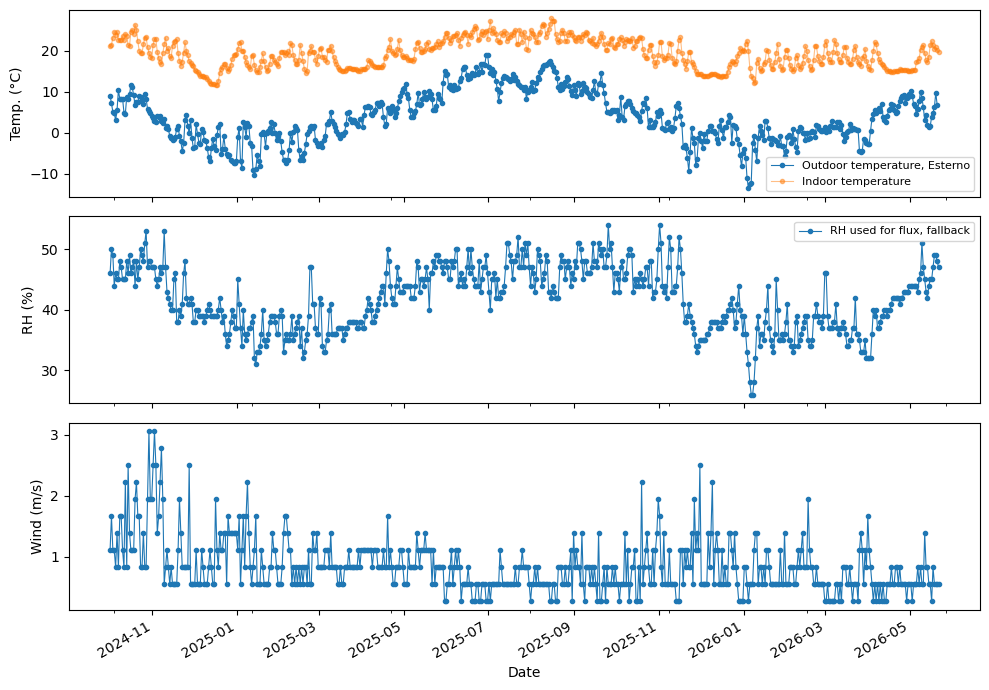

In [7]:
### Load cleaned weather station data


if not os.path.exists(weather_path):
    raise FileNotFoundError(
        "Weather file not found. Check this path: {}".format(weather_path)
    )

weather_raw = pd.read_csv(weather_path)

weather_time = pd.to_datetime(
    weather_raw["datetime_iso"],
    format="%d.%m.%Y %H:%M",   # format europeen jour.mois.annee
    errors="coerce"
)

weather = pd.DataFrame(index=weather_time)

weather["Tair_C"] = pd.to_numeric(weather_raw["Tair_C"], errors="coerce").to_numpy()

# No outdoor humidity column was present in the pasted file.
# Temporary fallback: use indoor humidity, but do not overinterpret latent heat flux.
weather["RH_inside_pct"] = pd.to_numeric(weather_raw["RH_inside_pct"], errors="coerce").to_numpy()
weather["RH_pct"] = weather["RH_inside_pct"]

weather["T_inside_C"] = pd.to_numeric(weather_raw["T_inside_C"], errors="coerce").to_numpy()
weather["pressure_hPa"] = pd.to_numeric(weather_raw["pressure_hPa"], errors="coerce").to_numpy()
weather["wind_dir_deg"] = pd.to_numeric(weather_raw["wind_dir_deg"], errors="coerce").to_numpy()
weather["U_kmh"] = pd.to_numeric(weather_raw["U_kmh"], errors="coerce").to_numpy()
weather["U10_m_s"] = pd.to_numeric(weather_raw["U10_m_s"], errors="coerce").to_numpy()
weather["gust_kmh"] = pd.to_numeric(weather_raw["gust_kmh"], errors="coerce").to_numpy()
weather["gust_dir_deg"] = pd.to_numeric(weather_raw["gust_dir_deg"], errors="coerce").to_numpy()

weather = weather[weather.index.notna()]
weather = weather[~weather.index.duplicated(keep="first")]
weather = weather.sort_index()

print("Weather loaded:")
print(weather.index.min(), "to", weather.index.max())

print("\nCheck that outdoor temperature is now used:")
display(weather[["Tair_C", "T_inside_C", "RH_pct", "U10_m_s", "pressure_hPa"]].head())

print("\nSummary:")
display(weather[["Tair_C", "T_inside_C", "RH_pct", "U10_m_s", "pressure_hPa"]].describe())

fig_weather, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

weather["Tair_C"].plot(ax=axes[0], marker=".", linewidth=0.8, label="Outdoor temperature, Esterno")
weather["T_inside_C"].plot(ax=axes[0], marker=".", linewidth=0.8, alpha=0.5, label="Indoor temperature")
axes[0].set_ylabel("Temp. (°C)")
axes[0].legend(fontsize=8)

weather["RH_pct"].plot(ax=axes[1], marker=".", linewidth=0.8, label="RH used for flux, fallback")
axes[1].set_ylabel("RH (%)")
axes[1].legend(fontsize=8)

weather["U10_m_s"].plot(ax=axes[2], marker=".", linewidth=0.8)
axes[2].set_ylabel("Wind (m/s)")
axes[2].set_xlabel("Date")

fig_weather.tight_layout()


Loaded radiation file:
  ../data/Meteo/Additional/ogd-smn_aig_d_historical.csv
  rows: 16436
Loaded radiation file:
  ../data/Meteo/Additional/ogd-smn_aig_d_recent.csv
  rows: 154

Combined radiation period:
1981-01-01 00:00:00 to 2026-06-03 00:00:00

Number of radiation rows: 16590

Radiation summary:


count    16590.000000
mean       145.614949
std         92.870272
min          0.000000
25%         66.000000
50%        128.000000
75%        221.000000
max        361.000000
Name: global_radiation_W_m2, dtype: float64

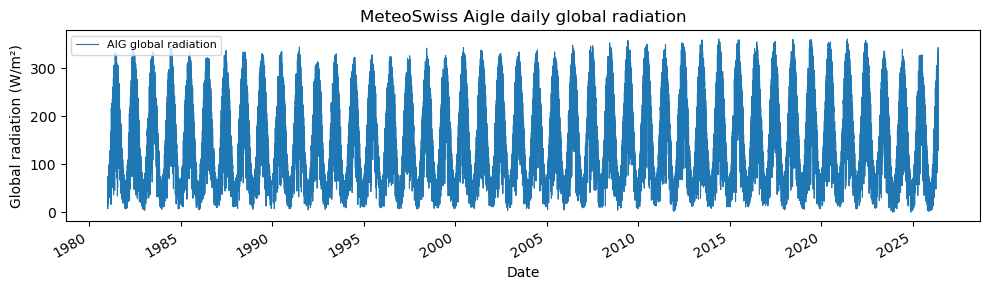

In [8]:
### Load MeteoSwiss Aigle daily global radiation, historical + recent


radiation_parts = []

for radiation_path in radiation_files:

    if not os.path.exists(radiation_path):
        raise FileNotFoundError(
            "Radiation file not found. Check this path: {}".format(radiation_path)
        )

    rad_raw = pd.read_csv(
        radiation_path,
        sep=";"
    )

    print("Loaded radiation file:")
    print(" ", radiation_path)
    print("  rows:", len(rad_raw))

    # Parse MeteoSwiss daily timestamp
    rad_time = pd.to_datetime(
        rad_raw["reference_timestamp"],
        format="%d.%m.%Y %H:%M",
        errors="coerce"
    )

    rad = pd.DataFrame(index=rad_time)

    # gre000d0 = daily global radiation
    rad["global_radiation_W_m2"] = pd.to_numeric(
        rad_raw["gre000d0"],
        errors="coerce"
    ).to_numpy()

    rad["station"] = rad_raw["station_abbr"].to_numpy()

    rad = rad[rad.index.notna()]
    radiation_parts.append(rad)


# Combine historical and recent files
radiation = pd.concat(radiation_parts)

# Remove duplicated dates, keeping the recent file if overlap exists
radiation = radiation[~radiation.index.duplicated(keep="last")]

# Sort chronologically
radiation = radiation.sort_index()

print("\nCombined radiation period:")
print(radiation.index.min(), "to", radiation.index.max())

print("\nNumber of radiation rows:", len(radiation))

print("\nRadiation summary:")
display(radiation["global_radiation_W_m2"].describe())


# Diagnostic plot
fig_radiation, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(
    radiation.index,
    radiation["global_radiation_W_m2"],
    linewidth=0.8,
    label="AIG global radiation"
)

ax.set_ylabel("Global radiation (W/m²)")
ax.set_xlabel("Date")
ax.set_title("MeteoSwiss Aigle daily global radiation")
ax.legend(fontsize=8)

fig_radiation.autofmt_xdate()
fig_radiation.tight_layout()


Cloud-cover file loaded:
../data/Meteo/Additional/cloud_cover_timeseries_Taney.csv

Columns:
0 : system:index
1 : cloud_cover_percent
2 : cloud_fraction
3 : date
4 : system_time_start
5 : .geo

First rows:


,system:index,cloud_cover_percent,cloud_fraction,date,system_time_start,.geo
0,tcdc_2024100100,92.300003,0.923,2024-10-01 00:00:00,1727740800000,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,tcdc_2024100106,76.400002,0.764,2024-10-01 06:00:00,1727762400000,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,tcdc_2024100112,99.400002,0.994,2024-10-01 12:00:00,1727784000000,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,tcdc_2024100118,71.000000,0.710,2024-10-01 18:00:00,1727805600000,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,tcdc_2024100200,82.099998,0.821,2024-10-02 00:00:00,1727827200000,"{""type"":""MultiPoint"",""coordinates"":[]}"



Cloud-cover period:
2024-10-01 02:00:00 to 2026-02-28 19:00:00

Cloud-cover summary:


,cloud_cover_percent,cloud_fraction
count,2064.000000,2064.000000
mean,43.625049,0.436250
std,34.872513,0.348725
min,0.000000,0.000000
25%,9.475000,0.094750
50%,39.350000,0.393500
75%,75.599998,0.756000
max,100.000000,1.000000


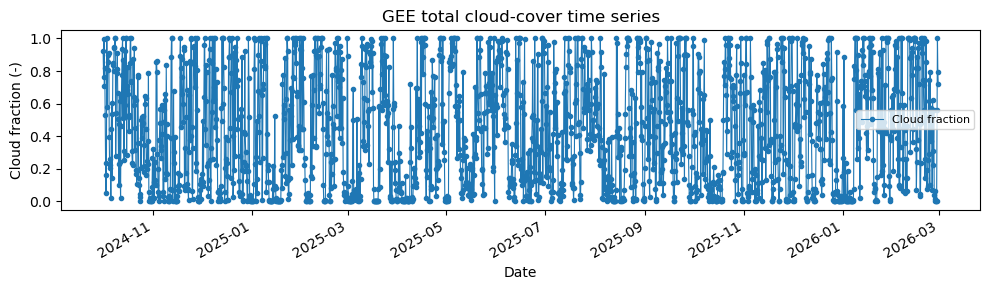

In [9]:
#### Load cloud-cover time series from Google Earth Engine export


if not os.path.exists(cloud_path):
    raise FileNotFoundError(
        "Cloud-cover file not found. Check this path: {}".format(cloud_path)
    )

cloud_raw = pd.read_csv(cloud_path)

print("Cloud-cover file loaded:")
print(cloud_path)

print("\nColumns:")
for i, col in enumerate(cloud_raw.columns):
    print(i, ":", col)

print("\nFirst rows:")
display(cloud_raw.head())


# ── Parse time ──────────────────────────────────────────────────────────────

# GEE system_time_start is in milliseconds since 1970 UTC.
# We convert it to local Europe/Zurich time to match the weather dataframe.

cloud_time = (
    pd.to_datetime(cloud_raw["system_time_start"], unit="ms", utc=True)
    .dt.tz_convert("Europe/Zurich")
    .dt.tz_localize(None)
)


# ── Build clean cloud-cover dataframe ───────────────────────────────────────

cloud_cover = pd.DataFrame(index=cloud_time)

cloud_cover["cloud_cover_percent"] = pd.to_numeric(
    cloud_raw["cloud_cover_percent"],
    errors="coerce"
).to_numpy()

cloud_cover["cloud_fraction"] = pd.to_numeric(
    cloud_raw["cloud_fraction"],
    errors="coerce"
).to_numpy()

# Keep cloud fraction physically bounded between 0 and 1.
cloud_cover["cloud_fraction"] = cloud_cover["cloud_fraction"].clip(0, 1)

cloud_cover = cloud_cover[~cloud_cover.index.duplicated(keep="first")]
cloud_cover = cloud_cover.sort_index()

print("\nCloud-cover period:")
print(cloud_cover.index.min(), "to", cloud_cover.index.max())

print("\nCloud-cover summary:")
display(cloud_cover.describe())


# ── Diagnostic plot ─────────────────────────────────────────────────────────

fig_cloud, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(
    cloud_cover.index,
    cloud_cover["cloud_fraction"],
    marker=".",
    linewidth=0.8,
    label="Cloud fraction"
)

ax.set_ylabel("Cloud fraction (-)")
ax.set_xlabel("Date")
ax.set_title("GEE total cloud-cover time series")
ax.legend(fontsize=8)

fig_cloud.autofmt_xdate()
fig_cloud.tight_layout()


## 2.5 Retrieval artefact diagnostic and cleaning

Assumption: points measured while the mooring is being retrieved are not representative of their nominal sensor depths. The diagnostic plot helps choose the cutoff. The cleaning cell keeps the time axis but replaces affected values with NaN, so the original alignment is preserved.

HOBO  t_end : 2026-01-18T04:39:00
mini  min   : 2025-06-06T06:48:00
mini  max   : 2026-06-03T13:37:00
ecart fin HOBO vs fin mini (h): 3272.9666666666667

Use this in the cleaning cell:
retrieval_cutoff_2026 = "2026-01-18 03:09:00"


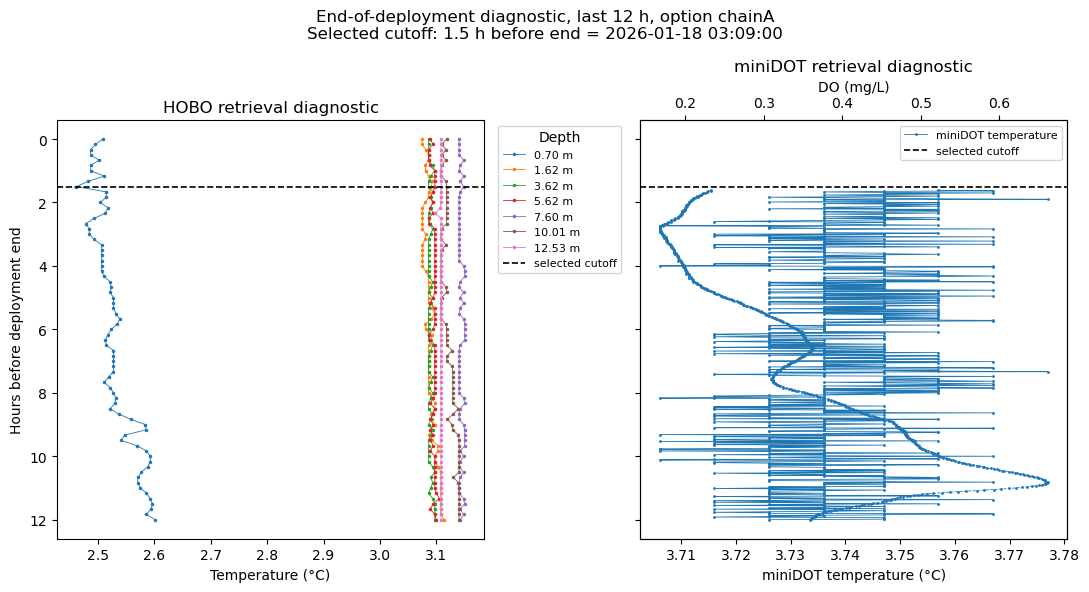

In [10]:
### End-of-deployment diagnostic: choose cutoff from hours before retrieval
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

hours_to_show = 12
cutoff_hours_before_end = 1.5   # change this after looking at the graph
option_to_check = "chainA"      # or "chainB"   <-- coquille corrigee

if option_to_check not in records_2026:
    raise ValueError(
        "option_to_check must be one of {}".format(list(records_2026.keys()))
    )

rec = records_2026[option_to_check]
t = rec["time"]
depth = rec["depth"]
temp = rec["temp"]

# depth peut etre une grille 2D (capteur x temps) -> on reduit a 1 valeur par capteur
depth = np.asarray(depth)
if depth.ndim > 1:
    depth = np.nanmean(depth, axis=1)

# ── HOBO: heures avant la fin du HOBO ───────────────────────────────────────
t_end = np.nanmax(t)
hours_before_end = (t_end - t) / 3600
mask = (hours_before_end >= 0) & (hours_before_end <= hours_to_show)   # borne des 2 cotes

# ── Diagnostic temps HOBO vs miniDOT (a regarder dans la sortie) ─────────────
if "mini_time_num" in globals():
    print("HOBO  t_end :", np.datetime64(int(np.nanmax(t)), "s"))
    print("mini  min   :", np.datetime64(int(np.nanmin(mini_time_num)), "s"))
    print("mini  max   :", np.datetime64(int(np.nanmax(mini_time_num)), "s"))
    print("ecart fin HOBO vs fin mini (h):",
          (np.nanmax(mini_time_num) - np.nanmax(t)) / 3600)

# Cutoff choisi -> datetime
cutoff_num = t_end - cutoff_hours_before_end * 3600
retrieval_cutoff_2026 = (
    np.datetime64(int(cutoff_num), "s").astype(datetime).strftime("%Y-%m-%d %H:%M:%S")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)

# ── HOBO temperatures ───────────────────────────────────────────────────────
for kd, d in enumerate(depth):
    axes[0].plot(
        temp[kd, mask],
        hours_before_end[mask],
        marker=".",
        markersize=3,
        linewidth=0.6,
        label="{:.2f} m".format(float(d))
    )
axes[0].axhline(cutoff_hours_before_end, linestyle="--", color="k",
                linewidth=1.2, label="selected cutoff")
axes[0].invert_yaxis()
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Hours before deployment end")
axes[0].set_title("HOBO retrieval diagnostic")
axes[0].legend(title="Depth", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

# ── miniDOT temperature and DO ──────────────────────────────────────────────
if "mini_time_num" in globals() and "mini_temp" in globals():
    mini_t_end = np.nanmax(mini_time_num)                      # fin PROPRE au miniDOT
    mini_hours_before_end = (mini_t_end - mini_time_num) / 3600
    mask_md = (mini_hours_before_end >= 0) & (mini_hours_before_end <= hours_to_show)

    axes[1].plot(
        mini_temp[mask_md],
        mini_hours_before_end[mask_md],
        marker=".", markersize=2, linewidth=0.6, label="miniDOT temperature"
    )
    if "mini_do" in globals():
        ax2 = axes[1].twiny()
        ax2.plot(
            mini_do[mask_md],
            mini_hours_before_end[mask_md],
            marker=".", markersize=2, linewidth=0.6, linestyle="--", label="miniDOT DO"
        )
        ax2.set_xlabel("DO (mg/L)")
    axes[1].axhline(cutoff_hours_before_end, linestyle="--", color="k",
                    linewidth=1.2, label="selected cutoff")
    axes[1].set_xlabel("miniDOT temperature (°C)")
    axes[1].set_title("miniDOT retrieval diagnostic")
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, "miniDOT not loaded",
                 ha="center", va="center", transform=axes[1].transAxes)

fig.suptitle(
    "End-of-deployment diagnostic, last {} h, option {}\nSelected cutoff: {} h before end = {}".format(
        hours_to_show, option_to_check, cutoff_hours_before_end, retrieval_cutoff_2026
    )
)
fig.tight_layout()
print("\nUse this in the cleaning cell:")
print('retrieval_cutoff_2026 = "{}"'.format(retrieval_cutoff_2026))

In [11]:
### Clean retrieval artefact for 2026 data only

# This cell removes the last unreliable measurements from the 2026 deployment.
#
# Why?
#   At the end of a deployment, the mooring is pulled up through the water column.
#   During that retrieval period, sensors are no longer at their nominal depths.
#   These final points can therefore create false signals in the temperature grid,
#   stratification timing, ice-cover timing, thermocline-depth estimates, and DO interpretation.
#
# What this cell does:
#   1) Keeps the raw 2026 data safely stored as records_2026_raw.
#   2) Creates cleaned copies where all values after the cutoff are set to NaN.
#   3) Updates the working 2026 and miniDOT variables used downstream.
#   4) Clears old derived variables, so the rest of the notebook must be rerun
#      and cannot accidentally use stale pre-cleaning results.
#
# Historical campaigns are not modified here.


# ── User input ──────────────────────────────────────────────────────────────

# Set this just before the retrieval artefact starts.
# Use the diagnostic plot above to choose this timestamp.
#
# Format:
#   "YYYY-MM-DD HH:MM:SS"

retrieval_cutoff_2026 = "2026-06-03 12:00:00"

# If True, the rest of the notebook will use the cleaned 2026 and miniDOT data.
# This is usually what you want for final analysis.

apply_cleaning_to_working_variables = True


# ── Preserve raw 2026 data once ─────────────────────────────────────────────

# These *_raw variables are created only the first time this cell is run.
# This means you can change retrieval_cutoff_2026 and rerun the cell safely.

if "records_2026_raw" not in globals():
    records_2026_raw = copy.deepcopy(records_2026)

if "mini_time_num" in globals() and "mini_time_num_raw" not in globals():
    mini_time_num_raw = mini_time_num.copy()
    mini_time_date_raw = mini_time_date.copy()
    mini_temp_raw = mini_temp.copy()
    mini_do_raw = mini_do.copy()
    mini_sat_raw = mini_sat.copy()


# ── Helper functions ────────────────────────────────────────────────────────

def datetime_string_to_unix_seconds(date_string):
    """
    Convert a date string to Unix seconds.
    """
    return np.datetime64(date_string, "s").astype("int64")


def clean_record_after_cutoff(record, cutoff_num):
    """
    Return one 2026 HOBO record with retrieval artefact values set to NaN.

    Temperatures after the cutoff are set to NaN.
    The time vector is kept unchanged so all arrays remain aligned.
    """

    r = copy.deepcopy(record)

    after_cutoff = r["time"] > cutoff_num

    if np.any(after_cutoff):
        r["temp"][:, after_cutoff] = np.nan

    return r, np.sum(after_cutoff)


# ── Apply cutoff to all 2026 HOBO options ───────────────────────────────────

cutoff_num = datetime_string_to_unix_seconds(retrieval_cutoff_2026)

print("Retrieval cutoff:", retrieval_cutoff_2026)

records_2026_clean = {}

for key, r in records_2026_raw.items():

    r_clean, n_cleaned = clean_record_after_cutoff(r, cutoff_num)
    records_2026_clean[key] = r_clean

    print(
        "2026 option {}: set {} time steps after cutoff to NaN".format(
            key,
            n_cleaned
        )
    )


# ── Apply cutoff to miniDOT ─────────────────────────────────────────────────

# miniDOT time is kept unchanged.
# Only temperature, dissolved oxygen, and saturation are set to NaN after the cutoff.

if "mini_time_num_raw" in globals():

    mini_time_num_clean = mini_time_num_raw.copy()
    mini_time_date_clean = mini_time_date_raw.copy()
    mini_temp_clean = mini_temp_raw.copy()
    mini_do_clean = mini_do_raw.copy()
    mini_sat_clean = mini_sat_raw.copy()

    after_cutoff_md = mini_time_num_clean > cutoff_num

    mini_temp_clean[after_cutoff_md] = np.nan
    mini_do_clean[after_cutoff_md] = np.nan
    mini_sat_clean[after_cutoff_md] = np.nan

    print(
        "miniDOT: set {} values after cutoff to NaN".format(
            np.sum(after_cutoff_md)
        )
    )

else:

    print("miniDOT variables not found. Only 2026 HOBO records were cleaned.")


# ── Update working variables if requested ──────────────────────────────────

if apply_cleaning_to_working_variables:

    records_2026 = copy.deepcopy(records_2026_clean)

    if "mini_time_num_clean" in globals():
        mini_time_num = mini_time_num_clean.copy()
        mini_time_date = mini_time_date_clean.copy()
        mini_temp = mini_temp_clean.copy()
        mini_do = mini_do_clean.copy()
        mini_sat = mini_sat_clean.copy()

    print("\nWorking 2026 variables now use cleaned data.")
    print("Historical records were not modified.")

    # Clear downstream variables that depend on records_2026 or miniDOT.
    # This prevents old pre-cleaning arrays from being reused accidentally.
    derived_variables_to_clear = [
        "records_for_analysis",
        "selected_record_2026",
        "deployment_info",
        "time_num",
        "time_date",
        "depth_grid",
        "temp_grid",
        "depth_common",
        "temp_common",
        "depth_sensors",
        "temp_sensors",
        "dT_surf_bot",
        "dT_bottom_surface",
        "stratified",
        "ice",
        "ice_periods",
        "thermocline_table",
        "thermocline_depth_m",
        "thermocline_depth_m_smooth",
        "thermocline_gradient_C_m",
        "mixed_open_water",
        "summary_df",
    ]

    for var_name in derived_variables_to_clear:
        if var_name in globals():
            del globals()[var_name]

    print("\nDownstream variables were cleared.")
    print("Now rerun the notebook from 'Analysis choices' onward.")

else:

    print("\nCleaned 2026 data were created but not applied.")
    print("Use records_2026_clean and mini_*_clean manually.")


Retrieval cutoff: 2026-06-03 12:00:00
2026 option chainA: set 0 time steps after cutoff to NaN
2026 option chainB: set 0 time steps after cutoff to NaN
2026 option unified: set 0 time steps after cutoff to NaN
miniDOT: set 97 values after cutoff to NaN

Working 2026 variables now use cleaned data.
Historical records were not modified.

Downstream variables were cleared.
Now rerun the notebook from 'Analysis choices' onward.


## 3. Data processing

## 3.1 Analysis choices

Change this cell when testing another campaign option, a different miniDOT choice, or different threshold assumptions.

In [12]:
### Analysis choices

# This is the main control cell for the analysis.
# Run the cleaning cell before this one if you want to remove retrieval artefacts.
#
# After changing any value here, rerun:
#   1) Build the final analysis records
#   2) Rebuild combined grids
#   3) Stratification / ice / thermocline / mixing cells

# ── Choose the 2026 HOBO option ─────────────────────────────────────────────

print("Available 2026 options:", list(records_2026.keys()))

selected_2026_option = "chainA"   # choose "chainA" or "chainB"


# ── Choose whether to add miniDOT temperature as the 2026 bottom sensor ─────

# If True:
#   miniDOT temperature is added as the deep/bottom sensor for 2026.
#
# If False:
#   analyses use only the shared HOBO depth interval.

use_minidot_as_bottom = True


# ── Stratification settings ─────────────────────────────────────────────────

# Stratification starts when the surface-bottom temperature difference
# exceeds this threshold for the selected minimum duration.

strat_threshold = 1.0       # °C
strat_min_hours = 48        # h


# ── Ice-cover settings ──────────────────────────────────────────────────────

# Ice cover is inferred from inverse stratification:
# bottom water warmer than surface water.
#
# Event logic:
#   Ice starts when bottom-surface ΔT >= ice_on_threshold for ice_min_on_hours.
#   Ice ends when bottom-surface ΔT <= ice_off_threshold for ice_min_off_hours.
#
# If ice_off_threshold is lower than ice_on_threshold, short noisy recrossings
# do not split the ice period.

ice_on_threshold = 0.10        # °C, start ice cover
ice_off_threshold = 0.00       # °C, end ice cover
ice_min_on_hours = 48          # h
ice_min_off_hours = 48         # h
keep_only_longest_ice_period = True


# ── Check choices and print status ──────────────────────────────────────────

if selected_2026_option not in records_2026:
    raise ValueError(
        "selected_2026_option '{}' not found.\n"
        "  Available options: {}\n"
        "  -> Update selected_2026_option in this cell.".format(
            selected_2026_option, list(records_2026.keys())
        )
    )

analysis_status = (
    "2026 option: {} | miniDOT bottom sensor: {}".format(
        selected_2026_option,
        "YES" if use_minidot_as_bottom else "NO"
    )
)

print(analysis_status)
print("Stratification threshold: ΔT ≥ {:.2f} °C for {} h".format(
    strat_threshold,
    strat_min_hours
))
print("Ice start: bottom-surface ΔT ≥ {:.2f} °C for {} h".format(
    ice_on_threshold,
    ice_min_on_hours
))
print("Ice end: bottom-surface ΔT ≤ {:.2f} °C for {} h".format(
    ice_off_threshold,
    ice_min_off_hours
))
print("Keep only longest ice-cover period:", keep_only_longest_ice_period)

# ── Thermocline-depth settings ──────────────────────────────────────────────

# Thermocline depth is estimated as the midpoint between the two adjacent
# real sensors with the strongest vertical temperature gradient.
#
# The gradient threshold avoids reporting a noisy thermocline during mixed periods.
# Set to 0.00 if you want a depth for every valid profile.

thermocline_min_abs_gradient_C_m = 0.05
thermocline_smoothing_hours = 24

print("Thermocline minimum |dT/dz|: {:.3f} °C/m".format(
    thermocline_min_abs_gradient_C_m
))
print("Thermocline smoothing window: {} h".format(
    thermocline_smoothing_hours
))


Available 2026 options: ['chainA', 'chainB', 'unified']
2026 option: chainA | miniDOT bottom sensor: YES
Stratification threshold: ΔT ≥ 1.00 °C for 48 h
Ice start: bottom-surface ΔT ≥ 0.10 °C for 48 h
Ice end: bottom-surface ΔT ≤ 0.00 °C for 48 h
Keep only longest ice-cover period: True
Thermocline minimum |dT/dz|: 0.050 °C/m
Thermocline smoothing window: 24 h


## 3.2 Build the final analysis records

In [13]:
import copy
import numpy as np

records_for_analysis = copy.deepcopy(historical_records)
selected_record_2026 = copy.deepcopy(records_2026[selected_2026_option])

# ── Normaliser depth en 1D (1 valeur par capteur) pour tous les records ──────
def _depth_1d(d):
    d = np.asarray(d)
    return np.nanmean(d, axis=1) if d.ndim > 1 else d

for r in records_for_analysis:
    r["depth"] = _depth_1d(r["depth"])
selected_record_2026["depth"] = _depth_1d(selected_record_2026["depth"])

if use_minidot_as_bottom:
    print("Adding miniDOT temperature as bottom sensor for 2026.")
    mini_temp_on_2026 = interp_with_nans(
        mini_time_num,
        mini_temp,
        selected_record_2026["time"]
    )
    if np.any(np.isclose(selected_record_2026["depth"], minidot_depth)):
        idx_existing = np.where(np.isclose(selected_record_2026["depth"], minidot_depth))[0][0]
        selected_record_2026["temp"][idx_existing, :] = mini_temp_on_2026
    else:
        selected_record_2026["depth"] = np.concatenate(
            (selected_record_2026["depth"], [minidot_depth]))
        selected_record_2026["temp"] = np.vstack(
            (selected_record_2026["temp"], mini_temp_on_2026))
        order = np.argsort(selected_record_2026["depth"])
        selected_record_2026["depth"] = selected_record_2026["depth"][order]
        selected_record_2026["temp"]  = selected_record_2026["temp"][order, :]
else:
    print("miniDOT temperature is not added to the 2026 profile.")

records_for_analysis.append(selected_record_2026)

print("\nFinal records for analysis:")
for r in records_for_analysis:
    print(
        "  {} | {} | depths {:.2f}-{:.2f} m | {} depths | {} time steps".format(
            r["camp"],
            r["label"],
            np.nanmin(r["depth"]),
            np.nanmax(r["depth"]),
            len(r["depth"]),
            len(r["time"])
        )
    )

Adding miniDOT temperature as bottom sensor for 2026.

Final records for analysis:
  20240527 | 20240527 | depths 0.00-25.00 m | 10 depths | 10515 time steps
  20240910 | 20240910 | depths 0.00-25.00 m | 9 depths | 15156 time steps
  20241126 | 20241126 | depths 0.00-25.00 m | 10 depths | 11076 time steps
  20250604 | 20250604 | depths 0.00-25.00 m | 10 depths | 5333 time steps
  20260603 | chainA | depths 0.70-31.80 m | 8 depths | 32509 time steps


## 3.3 Rebuild combined grids and raw sensor matrix

In [14]:
dz_plot = 0.1
dz_common = 0.1

global_min_depth = min(np.nanmin(r["depth"]) for r in records_for_analysis)
global_max_depth = max(np.nanmax(r["depth"]) for r in records_for_analysis)

depth_grid = np.arange(
    global_min_depth,
    global_max_depth + dz_plot / 2,
    dz_plot
)

common_min_depth = max(np.nanmin(r["depth"]) for r in records_for_analysis)
common_max_depth = min(np.nanmax(r["depth"]) for r in records_for_analysis)

depth_common = np.arange(
    common_min_depth,
    common_max_depth + dz_common / 2,
    dz_common
)

if depth_common[-1] > common_max_depth:
    depth_common[-1] = common_max_depth

if not np.isclose(depth_common[-1], common_max_depth):
    depth_common = np.concatenate((depth_common, [common_max_depth]))

print("Full plot depth grid: {:.2f}-{:.2f} m".format(depth_grid[0], depth_grid[-1]))
print("Common analysis depth grid: {:.2f}-{:.2f} m".format(depth_common[0], depth_common[-1]))

# Interpolate all selected deployments onto the two grids.
time_num = np.array([])
temp_grid = np.empty((len(depth_grid), 0))
temp_common = np.empty((len(depth_common), 0))

deployment_info = []

for r in records_for_analysis:
    temp_grid_add = interpolate_profile_to_grid(r["depth"], r["temp"], depth_grid)
    temp_common_add = interpolate_profile_to_grid(r["depth"], r["temp"], depth_common)

    time_num = np.concatenate((time_num, r["time"]))
    temp_grid = np.concatenate((temp_grid, temp_grid_add), axis=1)
    temp_common = np.concatenate((temp_common, temp_common_add), axis=1)

    deployment_info.append({
        "camp": r["camp"],
        "label": r["label"],
        "start_time": r["time"][0],
        "end_time": r["time"][-1],
        "depths": np.sort(r["depth"])
    })

# Sort combined arrays by time.
time_order = np.argsort(time_num)
time_num = time_num[time_order]
temp_grid = temp_grid[:, time_order]
temp_common = temp_common[:, time_order]
time_date = time_num.astype("datetime64[s]").astype(datetime)

# Raw sensor-depth matrix.
depth_sensors = np.unique(
    np.round(
        np.concatenate([r["depth"] for r in records_for_analysis]),
        2
    )
)

temp_sensors = np.full((len(depth_sensors), len(time_num)), np.nan)
time_lookup = {int(round(t)): i for i, t in enumerate(time_num)}

for r in records_for_analysis:
    depth_round = np.round(r["depth"], 2)

    for kt, t in enumerate(r["time"]):
        global_idx = time_lookup.get(int(round(t)))

        if global_idx is None:
            continue

        for kd, d in enumerate(depth_round):
            sensor_idx = np.where(np.isclose(depth_sensors, d))[0]

            if len(sensor_idx) > 0:
                temp_sensors[sensor_idx[0], global_idx] = r["temp"][kd, kt]

common_depth_text = "Common analysis depth: {:.2f}-{:.2f} m".format(depth_common[0], depth_common[-1])
plot_depth_text = "Full plotted depth: {:.2f}-{:.2f} m".format(depth_grid[0], depth_grid[-1])

print("\nUpdated combined dataset:")
print("  time:", time_date[0], "to", time_date[-1])
print("  temp_grid shape:", temp_grid.shape)
print("  temp_common shape:", temp_common.shape)
print("  depth_sensors:")
print(depth_sensors)
print("\n" + analysis_status)
print(common_depth_text)
print(plot_depth_text)


Full plot depth grid: 0.00-31.80 m
Common analysis depth grid: 0.70-25.00 m

Updated combined dataset:
  time: 2024-03-15 12:30:00 to 2026-01-18 04:39:00
  temp_grid shape: (319, 74589)
  temp_common shape: (244, 74589)
  depth_sensors:
[ 0.    0.7   1.62  2.5   3.62  5.    5.62  7.5   7.6  10.   10.01 12.5
 12.53 15.   17.5  20.   25.   31.8 ]

2026 option: chainA | miniDOT bottom sensor: YES
Common analysis depth: 0.70-25.00 m
Full plotted depth: 0.00-31.80 m


## 3.4 Metric helper for surface and bottom depths

In [15]:
### Metric depth-mode helper

# This cell decides which temperature profile is used for metrics.
#
# If miniDOT is not used:
#   metrics use the fixed common depth interval, depth_common/temp_common.
#
# If miniDOT is used:
#   metrics use all available depths in each deployment, depth_grid/temp_grid.
#   This allows the 2026 campaign to use the miniDOT as the bottom sensor.

def get_surface_bottom_for_metrics():
    """
    Return surface and bottom temperature series for stratification and ice-cover metrics.

    Output:
        T_surface
        T_bottom
        surface_depth_used
        bottom_depth_used
        metric_depth_mode
    """

    n = len(time_num)

    if use_minidot_as_bottom:

        # Check that the miniDOT was really included in the rebuilt grid.
        if "minidot_depth" in globals():
            if np.nanmax(depth_grid) < minidot_depth - 0.1:
                raise ValueError(
                    "use_minidot_as_bottom is True, but depth_grid does not reach the miniDOT depth. "
                    "Rerun the miniDOT addition and rebuild-grid cells."
                )

        T_surface = np.full(n, np.nan)
        T_bottom = np.full(n, np.nan)

        surface_depth_used = np.full(n, np.nan)
        bottom_depth_used = np.full(n, np.nan)

        for kt in range(n):

            ok = np.where(~np.isnan(temp_grid[:, kt]))[0]

            if len(ok) >= 2:

                surface_idx = ok[0]
                bottom_idx = ok[-1]

                T_surface[kt] = temp_grid[surface_idx, kt]
                T_bottom[kt] = temp_grid[bottom_idx, kt]

                surface_depth_used[kt] = depth_grid[surface_idx]
                bottom_depth_used[kt] = depth_grid[bottom_idx]

        metric_depth_mode = "available deployment-specific depths"

    else:

        T_surface = temp_common[0, :]
        T_bottom = temp_common[-1, :]

        surface_depth_used = np.full(n, depth_common[0])
        bottom_depth_used = np.full(n, depth_common[-1])

        metric_depth_mode = "fixed common depth interval"

    return T_surface, T_bottom, surface_depth_used, bottom_depth_used, metric_depth_mode


def apply_persistence(mask, time_num, min_hours, max_gap_factor=3):
    """
    Apply a persistence filter to a boolean mask.
    Large time gaps reset the run.
    """

    dt_sec = np.median(np.diff(time_num))
    nmin = int(round(min_hours * 3600 / dt_sec))

    out = np.zeros(len(mask), dtype=bool)

    run = 0

    for kt in range(len(mask)):

        if kt > 0:
            gap_too_large = (time_num[kt] - time_num[kt - 1]) > max_gap_factor * dt_sec
        else:
            gap_too_large = False

        if gap_too_large:
            run = 0

        if mask[kt]:
            run += 1
        else:
            run = 0

        if run >= nmin:
            out[kt - nmin + 1:kt + 1] = True

    return out


def print_metric_depth_summary(surface_depth_used, bottom_depth_used, metric_depth_mode):
    """
    Print which depths are used by the metric.
    """

    print("Metric depth mode:", metric_depth_mode)

    print(
        "Surface depth range used: {:.2f}-{:.2f} m".format(
            np.nanmin(surface_depth_used),
            np.nanmax(surface_depth_used)
        )
    )

    print(
        "Bottom depth range used: {:.2f}-{:.2f} m".format(
            np.nanmin(bottom_depth_used),
            np.nanmax(bottom_depth_used)
        )
    )


## 4. Mooring analysis and plots

## 4.1 Raw sensor time series

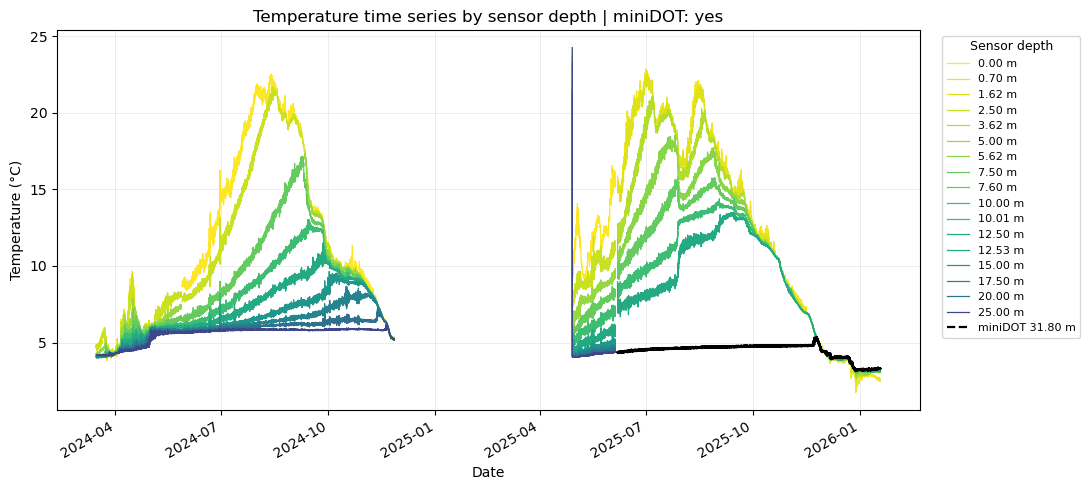

In [16]:
### Temperature time series by sensor depth
### Professional version with legend entries for valid sensors only


fig1, ax = plt.subplots(1, 1, figsize=(11, 5))

# ── Keep only depths that actually have data ────────────────────────────────

valid_depths_for_plot = []

for kd, d in enumerate(depth_sensors):
    y = temp_sensors[kd, :]

    if not np.all(np.isnan(y)):
        valid_depths_for_plot.append(d)

valid_depths_for_plot = np.array(valid_depths_for_plot)

if len(valid_depths_for_plot) == 0:
    raise ValueError("No valid temperature data found for plotting.")


# ── Depth colormap ──────────────────────────────────────────────────────────

cmap = plt.get_cmap("viridis_r")

norm = mpl.colors.Normalize(
    vmin=np.nanmin(valid_depths_for_plot),
    vmax=np.nanmax(valid_depths_for_plot)
)


# ── Plot temperature time series ────────────────────────────────────────────

for kd, d in enumerate(depth_sensors):

    y = temp_sensors[kd, :]

    if np.all(np.isnan(y)):
        continue

    line_color = cmap(norm(d))

    is_minidot = (
        use_minidot_as_bottom
        and "minidot_depth" in globals()
        and np.isclose(d, minidot_depth)
    )

    if is_minidot:

        ax.plot(
            time_date,
            y,
            color="black",
            linewidth=1.6,
            linestyle="--",
            label="miniDOT {:.2f} m".format(d),
            zorder=3
        )

    else:

        ax.plot(
            time_date,
            y,
            color=line_color,
            linewidth=0.9,
            label="{:.2f} m".format(d),
            zorder=2
        )


# ── Labels and title ────────────────────────────────────────────────────────

ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Date")

ax.set_title(
    "Temperature time series by sensor depth | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4
)


# ── Legend with only plotted sensors ────────────────────────────────────────

ax.legend(
    title="Sensor depth",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    ncol=1
)


fig1.autofmt_xdate()
fig1.tight_layout()


## 4.2 Interpolated temperature grid

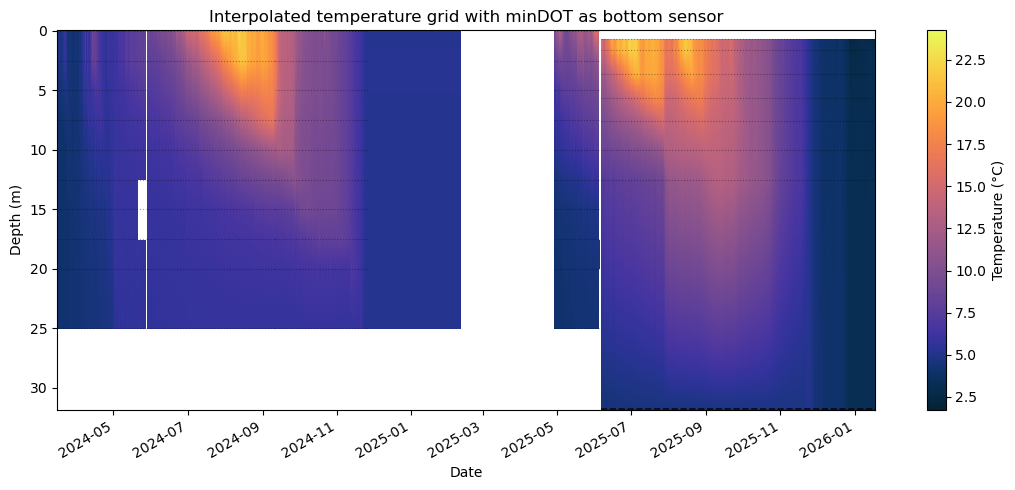

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

hp = ax.pcolormesh(
    time_date,
    depth_grid,
    temp_grid,
    cmap=cmap_temperature,
    shading="auto"
)

for info in deployment_info:
    start_date = np.datetime64(int(round(info["start_time"])), "s").astype(datetime)
    end_date = np.datetime64(int(round(info["end_time"])), "s").astype(datetime)

    for d in info["depths"]:
        if use_minidot_as_bottom and np.isclose(d, minidot_depth):
            ax.plot([start_date, end_date], [d, d], "--k", linewidth=1.2, alpha=0.8)
        else:
            ax.plot([start_date, end_date], [d, d], ":k", linewidth=0.8, alpha=0.35)

cb = plt.colorbar(hp, ax=ax)
cb.set_label("Temperature (°C)")

ax.invert_yaxis()
ax.set_ylabel("Depth (m)")
ax.set_xlabel("Date")
ax.set_title("Interpolated temperature grid with minDOT as bottom sensor")
    

fig.autofmt_xdate()
fig.tight_layout()


## 4.3 Stratification period

Assumption: stratification is inferred from a sustained surface-bottom temperature difference. The threshold and persistence duration are defined in the analysis choices cell.

2026 option: chainA | miniDOT bottom sensor: YES
Metric depth mode: available deployment-specific depths
Surface depth range used: 0.00-17.60 m
Bottom depth range used: 20.00-31.80 m
Stratification threshold: ΔT ≥ 1.00 °C
Persistence filter: 48 h
Stratified duration: 413.8 days


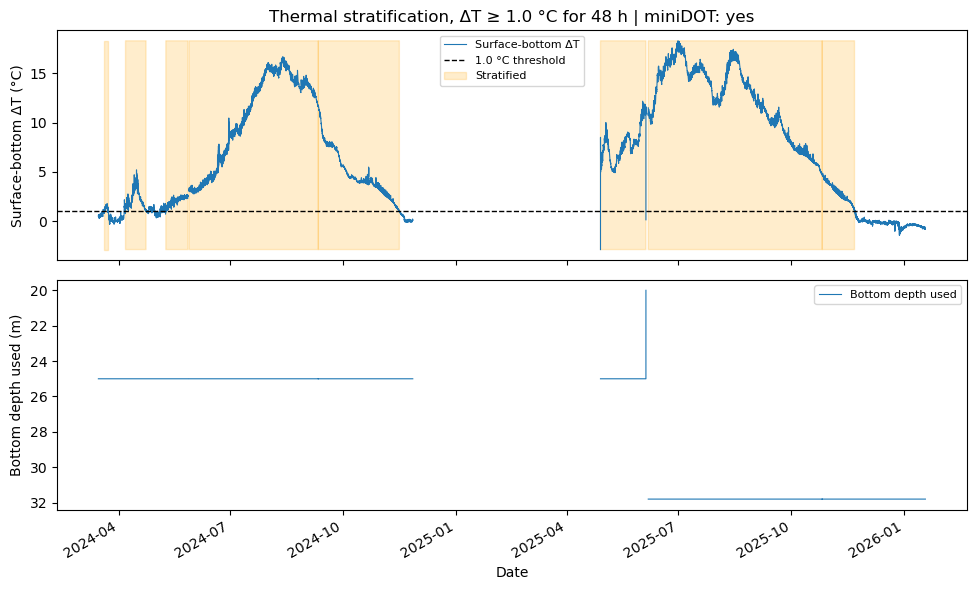

In [18]:
### Stratification period

T_surface, T_bottom, surface_depth_used, bottom_depth_used, metric_depth_mode = get_surface_bottom_for_metrics()

dT_surf_bot = T_surface - T_bottom

strat_raw = np.nan_to_num(dT_surf_bot, nan=-999) >= strat_threshold
stratified = apply_persistence(strat_raw, time_num, strat_min_hours)

dt_sec = np.median(np.diff(time_num))
strat_days = stratified.sum() * dt_sec / 86400

strat_runs = find_continuous_runs(stratified, time_num)
strat_periods = [
    (start, end)
    for start, end, _ in strat_runs
]

print(analysis_status)
print_metric_depth_summary(surface_depth_used, bottom_depth_used, metric_depth_mode)
print("Stratification threshold: ΔT ≥ {:.2f} °C".format(strat_threshold))
print("Persistence filter: {} h".format(strat_min_hours))
print("Stratified duration: {:.1f} days".format(strat_days))

fig3, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(
    time_date,
    dT_surf_bot,
    linewidth=0.8,
    label="Surface-bottom ΔT"
)

axes[0].axhline(
    strat_threshold,
    linestyle="--",
    color="k",
    linewidth=1,
    label="{:.1f} °C threshold".format(strat_threshold)
)

axes[0].fill_between(
    time_date,
    np.nanmin(dT_surf_bot),
    np.nanmax(dT_surf_bot),
    where=stratified,
    alpha=0.2,
    color="orange",
    label="Stratified"
)

axes[0].set_ylabel("Surface-bottom ΔT (°C)")
axes[0].set_title(
    f"Thermal stratification, ΔT ≥ {strat_threshold:.1f} °C for {strat_min_hours} h | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)

axes[0].legend(fontsize=8)

axes[1].plot(
    time_date,
    bottom_depth_used,
    linewidth=0.8,
    label="Bottom depth used"
)

axes[1].invert_yaxis()
axes[1].set_ylabel("Bottom depth used (m)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)

fig3.autofmt_xdate()
fig3.tight_layout()


## 4.4 Ice cover from inverse stratification

Assumption: ice cover is inferred when bottom water remains warmer than surface water for long enough. The start and end thresholds are separated to avoid breaking one ice period because of short noisy recrossings.

2026 option: chainA | miniDOT bottom sensor: YES
Metric depth mode: available deployment-specific depths
Surface depth range used: 0.00-17.60 m
Bottom depth range used: 20.00-31.80 m
Ice start threshold: bottom-surface ΔT ≥ 0.10 °C for 48 h
Ice end threshold: bottom-surface ΔT ≤ 0.00 °C for 48 h
Total inferred ice-covered duration: 32.54 days

Detected ice-cover period(s):
  Period 1: 2025-12-16 to 2026-01-18  (32.54 days)
Total inferred ice-covered duration: 32.54 days


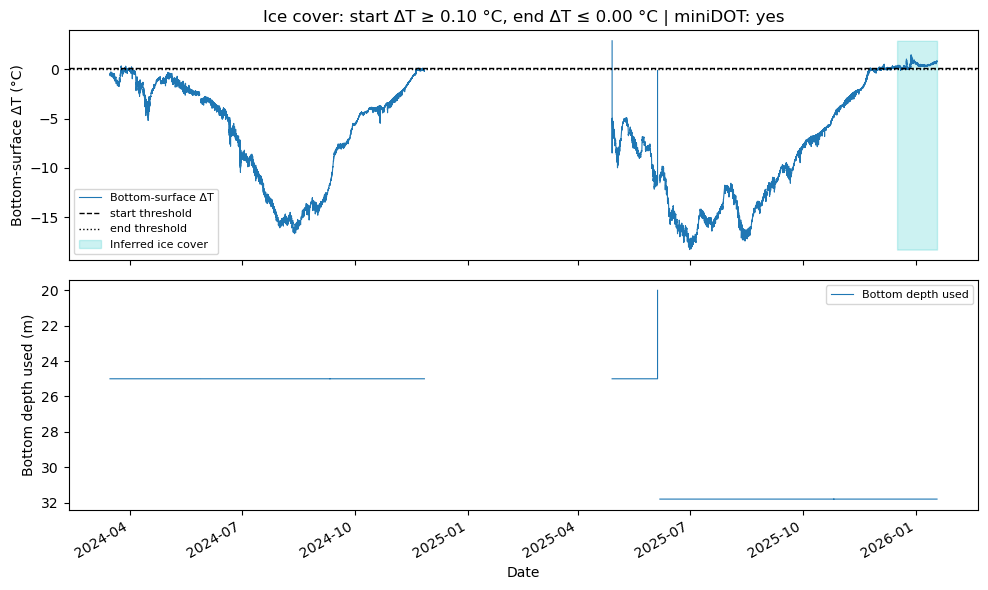

In [19]:
### Ice-cover detection from inverse stratification with start/end thresholds

# Ice cover is inferred from inverse winter stratification:
# bottom water is warmer than surface water.
#
# Event logic:
#   ice starts when bottom-surface ΔT >= ice_on_threshold for ice_min_on_hours
#   ice ends when bottom-surface ΔT <= ice_off_threshold for ice_min_off_hours
#
# The lower off-threshold avoids breaking the ice-cover period because of short noise.
# If you want no hysteresis, set ice_off_threshold = ice_on_threshold.

T_surface, T_bottom, surface_depth_used, bottom_depth_used, metric_depth_mode = get_surface_bottom_for_metrics()

dT_bottom_surface = T_bottom - T_surface

valid_pair = ~np.isnan(T_surface) & ~np.isnan(T_bottom)

ice_on_raw = valid_pair & (dT_bottom_surface >= ice_on_threshold)
ice_off_raw = valid_pair & (dT_bottom_surface <= ice_off_threshold)

dt_sec = np.median(np.diff(time_num))
max_gap_factor = 3

n_on = int(round(ice_min_on_hours * 3600 / dt_sec))
n_off = int(round(ice_min_off_hours * 3600 / dt_sec))


# ── Event detection ─────────────────────────────────────────────────────────

ice_periods = []

in_ice = False
run_on = 0
run_off = 0
ice_start = None

for kt in range(len(time_num)):

    if kt > 0:
        gap_too_large = (time_num[kt] - time_num[kt - 1]) > max_gap_factor * dt_sec
    else:
        gap_too_large = False

    # A large data gap closes the current event at the previous time step.
    if gap_too_large:

        if in_ice and ice_start is not None:
            ice_end = kt - 1
            ice_periods.append((ice_start, ice_end))

        in_ice = False
        run_on = 0
        run_off = 0
        ice_start = None


    if not in_ice:

        # Before ice cover:
        # wait until inverse stratification is sustained long enough.

        if ice_on_raw[kt]:
            run_on += 1
        else:
            run_on = 0

        if run_on >= n_on:
            ice_start = kt - n_on + 1
            in_ice = True
            run_off = 0


    else:

        # During ice cover:
        # keep the event until the off-threshold is recrossed for long enough.

        if ice_off_raw[kt]:
            run_off += 1
        else:
            run_off = 0

        if run_off >= n_off:

            off_start = kt - n_off + 1
            ice_end = off_start - 1

            if ice_end >= ice_start:
                ice_periods.append((ice_start, ice_end))

            in_ice = False
            run_on = 0
            run_off = 0
            ice_start = None


# If the time series ends while still in an ice event, close it at the last time step.
if in_ice and ice_start is not None:
    ice_periods.append((ice_start, len(time_num) - 1))


# ── Optionally keep only the longest ice-cover period ───────────────────────

if keep_only_longest_ice_period and len(ice_periods) > 1:

    durations = [
        end - start + 1
        for start, end in ice_periods
    ]

    longest_idx = np.argmax(durations)
    ice_periods = [ice_periods[longest_idx]]


# ── Create final ice-cover mask ─────────────────────────────────────────────

ice = np.zeros(len(time_num), dtype=bool)

for ice_start, ice_end in ice_periods:
    ice[ice_start:ice_end + 1] = True

ice_days = ice.sum() * dt_sec / 86400


# ── Print summary ───────────────────────────────────────────────────────────

print(analysis_status)
print_metric_depth_summary(surface_depth_used, bottom_depth_used, metric_depth_mode)

print("Ice start threshold: bottom-surface ΔT ≥ {:.2f} °C for {} h".format(
    ice_on_threshold,
    ice_min_on_hours
))

print("Ice end threshold: bottom-surface ΔT ≤ {:.2f} °C for {} h".format(
    ice_off_threshold,
    ice_min_off_hours
))

print("Total inferred ice-covered duration: {:.2f} days".format(ice_days))

if len(ice_periods) > 0:

    print("\nDetected ice-cover period(s):")

    for i, (ice_start, ice_end) in enumerate(ice_periods, start=1):

        dur_days = (ice_end - ice_start + 1) * dt_sec / 86400

        print(
            "  Period {}: {} to {}  ({:.2f} days)".format(
                i,
                time_date[ice_start].date(),
                time_date[ice_end].date(),
                dur_days
            )
        )

else:

    print("No sustained ice-cover period detected.")


# ── Plot ice-cover diagnostic ───────────────────────────────────────────────

fig_ice, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(
    time_date,
    dT_bottom_surface,
    linewidth=0.8,
    label="Bottom-surface ΔT"
)

axes[0].axhline(
    ice_on_threshold,
    linestyle="--",
    color="k",
    linewidth=1,
    label="start threshold"
)

axes[0].axhline(
    ice_off_threshold,
    linestyle=":",
    color="k",
    linewidth=1,
    label="end threshold"
)

if ice.any():

    axes[0].fill_between(
        time_date,
        np.nanmin(dT_bottom_surface),
        np.nanmax(dT_bottom_surface),
        where=ice,
        alpha=0.2,
        color="c",
        label="Inferred ice cover"
    )

axes[0].set_ylabel("Bottom-surface ΔT (°C)")
axes[0].set_title(
    f"Ice cover: start ΔT ≥ {ice_on_threshold:.2f} °C, end ΔT ≤ {ice_off_threshold:.2f} °C | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)

axes[0].legend(fontsize=8)


axes[1].plot(
    time_date,
    bottom_depth_used,
    linewidth=0.8,
    label="Bottom depth used"
)

axes[1].invert_yaxis()
axes[1].set_ylabel("Bottom depth used (m)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)

fig_ice.autofmt_xdate()
fig_ice.tight_layout()
print("Total inferred ice-covered duration: {:.2f} days".format(ice_days))


## 4.5 Thermocline depth from strongest sensor gradient

The thermocline is estimated from the strongest vertical temperature gradient between adjacent real sensors.

Thermocline method: strongest vertical gradient on interpolated temperature grid
Minimum |dT/dz| threshold: 0.050 °C/m
Smoothing window: 24 h
Open-water stratified duration: 413.8 days
Ice-cover duration: 32.5 days
Mixed or transitional duration: 71.6 days
Median thermocline depth: 5.30 m
Mean thermocline depth: 9.22 m


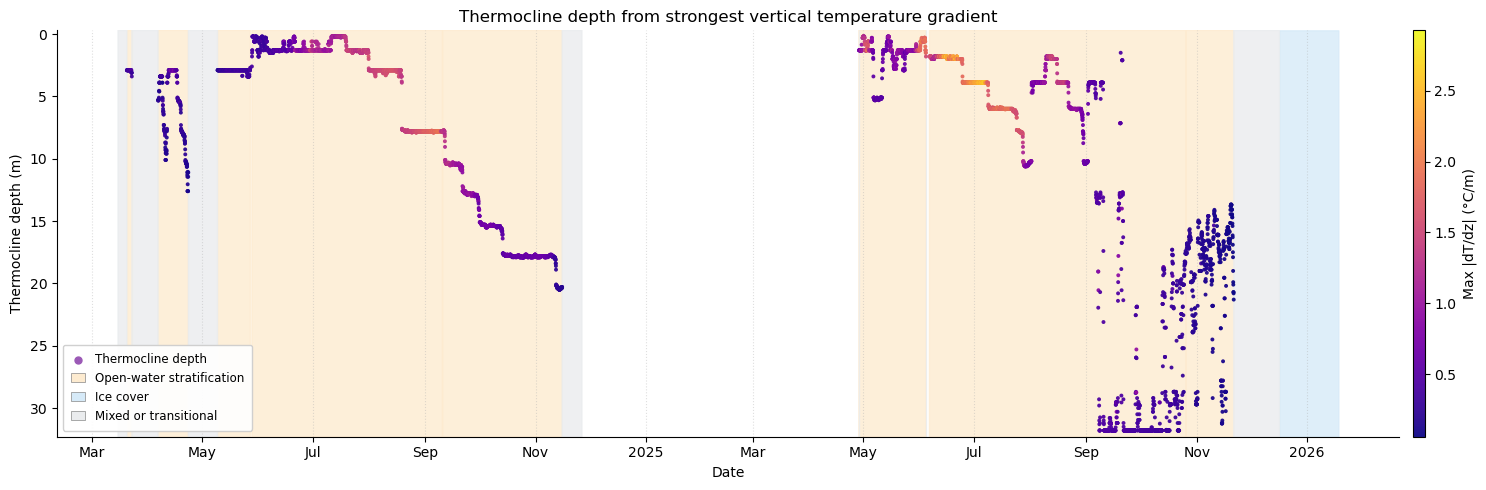

In [20]:
### Thermocline depth from strongest vertical temperature gradient

# This cell assumes that the following cells have already been run:
#   1) Rebuild combined grids
#   2) Stratification period
#   3) Ice-cover detection
#
# The thermocline is estimated as the depth of the strongest vertical
# temperature gradient on the already-interpolated temperature grid.

required_variables = [
    "temp_grid",
    "depth_grid",
    "time_date",
    "time_num",
    "stratified"
]

for var in required_variables:
    if var not in globals():
        raise ValueError(f"Missing variable: {var}. Run the previous processing cells first.")

if "thermocline_min_abs_gradient_C_m" not in globals():
    thermocline_min_abs_gradient_C_m = 0.1

if "thermocline_smoothing_hours" not in globals():
    thermocline_smoothing_hours = 1


# ── Prepare inputs ──────────────────────────────────────────────────────────

time_dt = pd.to_datetime(time_date)

z = np.asarray(depth_grid, dtype=float)
T = np.asarray(temp_grid, dtype=float)

depth_order = np.argsort(z)
z_sorted = z[depth_order]
T_sorted = T[depth_order, :]

n_time = T_sorted.shape[1]

stratified_mask = np.asarray(stratified, dtype=bool)

if "ice" in globals():
    ice_mask = np.asarray(ice, dtype=bool)
else:
    ice_mask = np.zeros(n_time, dtype=bool)

valid_profile = np.any(np.isfinite(T_sorted), axis=0)

open_water_stratified = (
    valid_profile
    & stratified_mask
    & (~ice_mask)
)

mixed_or_transitional = (
    valid_profile
    & (~stratified_mask)
    & (~ice_mask)
)


# ── Compute strongest vertical gradient ─────────────────────────────────────

with np.errstate(invalid="ignore"):
    dTdz = np.gradient(T_sorted, z_sorted, axis=0)

abs_dTdz = np.abs(dTdz)

# Thermocline is only defined during open-water stratification.
abs_dTdz[:, ~open_water_stratified] = np.nan

finite_gradient = np.isfinite(abs_dTdz)
has_valid_gradient = np.any(finite_gradient, axis=0)

abs_for_argmax = np.where(finite_gradient, abs_dTdz, -np.inf)
strongest_gradient_index = np.argmax(abs_for_argmax, axis=0)

time_index = np.arange(n_time)

max_abs_gradient_C_m = np.full(n_time, np.nan)
thermocline_depth_m_raw = np.full(n_time, np.nan)
thermocline_gradient_C_m = np.full(n_time, np.nan)

valid_thermocline = (
    has_valid_gradient
    & np.isfinite(abs_for_argmax[strongest_gradient_index, time_index])
)

max_abs_gradient_C_m[valid_thermocline] = abs_dTdz[
    strongest_gradient_index[valid_thermocline],
    time_index[valid_thermocline]
]

valid_thermocline = (
    valid_thermocline
    & (max_abs_gradient_C_m >= thermocline_min_abs_gradient_C_m)
)

thermocline_depth_m_raw[valid_thermocline] = z_sorted[
    strongest_gradient_index[valid_thermocline]
]

thermocline_gradient_C_m[valid_thermocline] = dTdz[
    strongest_gradient_index[valid_thermocline],
    time_index[valid_thermocline]
]


# ── Smooth thermocline depth ────────────────────────────────────────────────

dt_sec = np.median(np.diff(time_num))
smooth_window_steps = max(
    1,
    int(round(thermocline_smoothing_hours * 3600 / dt_sec))
)

thermocline_depth_m = (
    pd.Series(thermocline_depth_m_raw, index=time_dt)
    .rolling(
        window=smooth_window_steps,
        center=True,
        min_periods=1
    )
    .median()
    .to_numpy()
)

thermocline_depth_m[np.isnan(thermocline_depth_m_raw)] = np.nan


# ── Store output table ──────────────────────────────────────────────────────

thermocline_table = pd.DataFrame(
    {
        "thermocline_depth_m_raw": thermocline_depth_m_raw,
        "thermocline_depth_m": thermocline_depth_m,
        "thermocline_gradient_C_m": thermocline_gradient_C_m,
        "thermocline_abs_gradient_C_m": max_abs_gradient_C_m,
        "stratified": stratified_mask,
        "ice_cover": ice_mask,
        "open_water_stratified": open_water_stratified,
        "mixed_or_transitional": mixed_or_transitional
    },
    index=time_dt
)


# ── Summary ─────────────────────────────────────────────────────────────────

dt_days = dt_sec / 86400

stratified_days = np.sum(open_water_stratified) * dt_days
ice_days = np.sum(ice_mask & valid_profile) * dt_days
mixed_days = np.sum(mixed_or_transitional) * dt_days

print("Thermocline method: strongest vertical gradient on interpolated temperature grid")
print("Minimum |dT/dz| threshold: {:.3f} °C/m".format(
    thermocline_min_abs_gradient_C_m
))
print("Smoothing window: {} h".format(thermocline_smoothing_hours))
print("Open-water stratified duration: {:.1f} days".format(stratified_days))
print("Ice-cover duration: {:.1f} days".format(ice_days))
print("Mixed or transitional duration: {:.1f} days".format(mixed_days))

if np.isfinite(thermocline_depth_m).any():
    print("Median thermocline depth: {:.2f} m".format(
        np.nanmedian(thermocline_depth_m)
    ))
    print("Mean thermocline depth: {:.2f} m".format(
        np.nanmean(thermocline_depth_m)
    ))
else:
    print("No valid thermocline depth found.")


# ── Plot ────────────────────────────────────────────────────────────────────

thermocline_plot_max_points = 8000

valid_plot = (
    np.isfinite(thermocline_depth_m)
    & np.isfinite(max_abs_gradient_C_m)
)

plot_indices = np.where(valid_plot)[0]

if len(plot_indices) > thermocline_plot_max_points:
    plot_step = int(np.ceil(len(plot_indices) / thermocline_plot_max_points))
    plot_indices = plot_indices[::plot_step]

fig_thermocline, ax = plt.subplots(figsize=(15, 5))

y_top = z_sorted[0] - 0.3
y_bottom = z_sorted[-1] + 0.5

ax.fill_between(
    time_dt,
    y_top,
    y_bottom,
    where=open_water_stratified,
    color="#FDEBD0",
    alpha=0.8,
    zorder=0
)

ax.fill_between(
    time_dt,
    y_top,
    y_bottom,
    where=ice_mask & valid_profile,
    color="#D6EAF8",
    alpha=0.8,
    zorder=0
)

ax.fill_between(
    time_dt,
    y_top,
    y_bottom,
    where=mixed_or_transitional,
    color="#EAECEE",
    alpha=0.8,
    zorder=0
)

sc = ax.scatter(
    time_dt[plot_indices],
    thermocline_depth_m[plot_indices],
    c=max_abs_gradient_C_m[plot_indices],
    cmap="plasma",
    s=8,
    linewidths=0,
    alpha=0.95,
    zorder=4
)

cb = fig_thermocline.colorbar(
    sc,
    ax=ax,
    pad=0.01,
    fraction=0.018,
    aspect=35
)

cb.set_label("Max |dT/dz| (°C/m)")

ax.set_ylim(y_bottom, y_top)
ax.set_ylabel("Thermocline depth (m)")
ax.set_xlabel("Date")
ax.set_title("Thermocline depth from strongest vertical temperature gradient")

loc = mdates.AutoDateLocator(minticks=8, maxticks=14)
ax.xaxis.set_major_locator(loc)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

ax.grid(axis="x", linestyle=":", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    plt.scatter(
        [],
        [],
        c="#9b59b6",
        s=25,
        label="Thermocline depth"
    ),
    mpl.patches.Patch(
        facecolor="#FDEBD0",
        edgecolor="#888888",
        linewidth=0.5,
        label="Open-water stratification"
    ),
    mpl.patches.Patch(
        facecolor="#D6EAF8",
        edgecolor="#888888",
        linewidth=0.5,
        label="Ice cover"
    ),
    mpl.patches.Patch(
        facecolor="#EAECEE",
        edgecolor="#888888",
        linewidth=0.5,
        label="Mixed or transitional"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=8.5,
    framealpha=0.92,
    handlelength=1.2,
    borderpad=0.7,
    edgecolor="#cccccc"
)

fig_thermocline.tight_layout()


## 4.6 Thermal states and miniDOT dissolved oxygen


Summary table of detected periods:


,period_type,period_number,start_date,end_date,duration_days
0,Stratified,1,2024-03-20,2024-03-23,2.8
1,Stratified,2,2024-04-06,2024-04-23,16.7
2,Stratified,3,2024-05-09,2024-05-27,18.1
3,Stratified,4,2024-05-28,2024-09-10,105.2
4,Stratified,5,2024-09-10,2024-11-15,66.0
5,Stratified,6,2025-04-28,2025-06-04,37.0
6,Stratified,7,2025-06-06,2025-10-26,141.7
7,Stratified,8,2025-10-26,2025-11-21,26.3
8,Ice cover,1,2025-12-16,2026-01-18,32.5
9,Mixing period,1,2024-03-15,2024-03-20,4.9


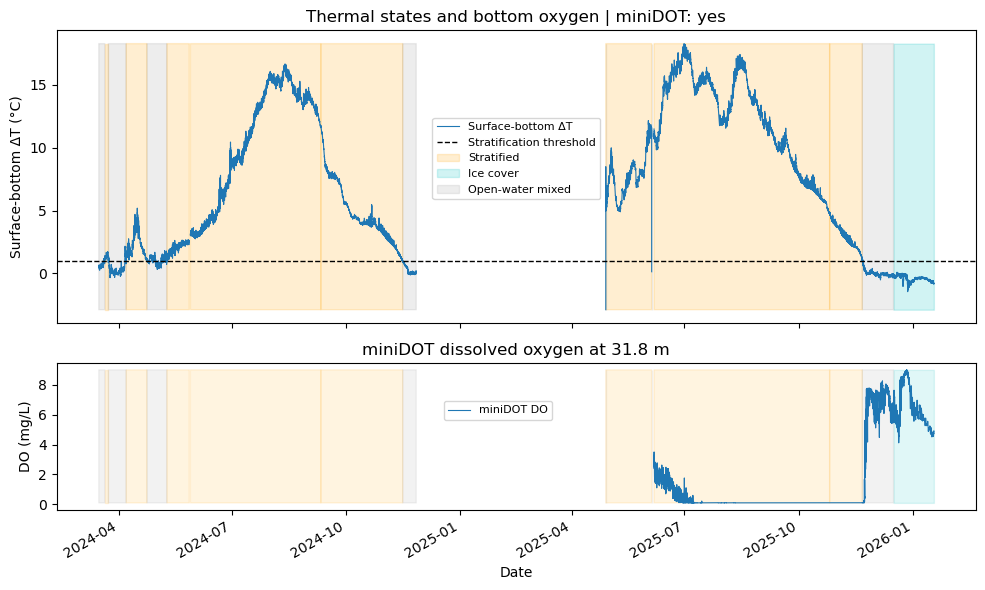

In [21]:
### Seasonal thermal states and miniDOT dissolved oxygen

# Assumption:
#   Open-water mixed periods are defined as valid surface-bottom observations
#   that are neither stratified nor ice-covered.
#
# This avoids hard-coding spring and autumn labels, which is fragile when new
# campaigns are added or when only part of a year is available.

if "dT_surf_bot" not in globals():
    raise ValueError("Run the stratification cell first.")

if "ice" not in globals():
    raise ValueError("Run the ice-cover cell first.")

valid_thermal_state = np.isfinite(dT_surf_bot)

mixed_open_water = valid_thermal_state & (~stratified) & (~ice)

mixed_runs = find_continuous_runs(mixed_open_water, time_num)
mixed_periods = [
    (start, end)
    for start, end, _ in mixed_runs
]


# ── Interpolate miniDOT DO onto the main time axis ──────────────────────────

do_on_time = np.full(len(time_num), np.nan)

if "mini_time_num" in globals() and "mini_do" in globals():

    valid_do = np.isfinite(mini_time_num) & np.isfinite(mini_do)

    if np.sum(valid_do) >= 2:

        x_do = mini_time_num[valid_do]
        y_do = mini_do[valid_do]

        order = np.argsort(x_do)
        x_do = x_do[order]
        y_do = y_do[order]

        inside = (time_num >= x_do[0]) & (time_num <= x_do[-1])

        do_on_time[inside] = np.interp(
            time_num[inside],
            x_do,
            y_do
        )

    else:
        print("miniDOT DO exists, but not enough valid values to interpolate.")

else:
    print("miniDOT DO variables not found. Run the miniDOT loading cell first.")


fig_mix, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)


# ── Top panel: thermal states ───────────────────────────────────────────────

ax = axes[0]

ax.plot(
    time_date,
    dT_surf_bot,
    linewidth=0.8,
    label="Surface-bottom ΔT"
)

ax.axhline(
    strat_threshold,
    linestyle="--",
    color="k",
    linewidth=1,
    label="Stratification threshold"
)

ymin = np.nanmin(dT_surf_bot)
ymax = np.nanmax(dT_surf_bot)

ax.fill_between(
    time_date,
    ymin,
    ymax,
    where=stratified,
    alpha=0.18,
    color="orange",
    label="Stratified"
)

ax.fill_between(
    time_date,
    ymin,
    ymax,
    where=ice,
    alpha=0.18,
    color="c",
    label="Ice cover"
)

ax.fill_between(
    time_date,
    ymin,
    ymax,
    where=mixed_open_water,
    alpha=0.14,
    color="grey",
    label="Open-water mixed"
)

ax.set_ylabel("Surface-bottom ΔT (°C)")
ax.set_title(
    "Thermal states and bottom oxygen | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)

ax.legend(
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.50, 0.72)
)


# ── Bottom panel: miniDOT dissolved oxygen ──────────────────────────────────

ax = axes[1]

ax.plot(
    time_date,
    do_on_time,
    linewidth=0.8,
    label="miniDOT DO"
)

if np.any(np.isfinite(do_on_time)):

    ymin_do = np.nanmin(do_on_time)
    ymax_do = np.nanmax(do_on_time)

    ax.fill_between(
        time_date,
        ymin_do,
        ymax_do,
        where=stratified,
        alpha=0.12,
        color="orange"
    )

    ax.fill_between(
        time_date,
        ymin_do,
        ymax_do,
        where=ice,
        alpha=0.12,
        color="c"
    )

    ax.fill_between(
        time_date,
        ymin_do,
        ymax_do,
        where=mixed_open_water,
        alpha=0.10,
        color="grey"
    )

else:

    ax.text(
        0.5,
        0.5,
        "No miniDOT DO available",
        ha="center",
        va="center",
        transform=ax.transAxes
    )

ax.set_ylabel("DO (mg/L)")
ax.set_xlabel("Date")

if "minidot_depth" in globals():
    ax.set_title(f"miniDOT dissolved oxygen at {minidot_depth:.1f} m")
else:
    ax.set_title("miniDOT dissolved oxygen")

ax.legend(
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.48, 0.78)
)

fig_mix.autofmt_xdate()
fig_mix.tight_layout()


# ── Summary table of period start/end dates ─────────────────────────────────

def period_duration_days(start, end, time_num):
    """Duration of a detected period in days."""
    return (time_num[end] - time_num[start]) / 86400


period_rows = []

# Stratified periods
for i, (start, end) in enumerate(strat_periods, start=1):
    period_rows.append({
        "period_type": "Stratified",
        "period_number": i,
        "start_date": time_date[start].strftime("%Y-%m-%d"),
        "end_date": time_date[end].strftime("%Y-%m-%d"),
        "duration_days": period_duration_days(start, end, time_num)
    })

# Ice-covered periods
for i, (start, end) in enumerate(ice_periods, start=1):
    period_rows.append({
        "period_type": "Ice cover",
        "period_number": i,
        "start_date": time_date[start].strftime("%Y-%m-%d"),
        "end_date": time_date[end].strftime("%Y-%m-%d"),
        "duration_days": period_duration_days(start, end, time_num)
    })

# Open-water mixed periods
for i, (start, end) in enumerate(mixed_periods, start=1):
    period_rows.append({
        "period_type": "Mixing period",
        "period_number": i,
        "start_date": time_date[start].strftime("%Y-%m-%d"),
        "end_date": time_date[end].strftime("%Y-%m-%d"),
        "duration_days": period_duration_days(start, end, time_num)
    })

period_table = pd.DataFrame(period_rows)

if len(period_table) > 0:

    period_table["duration_days"] = period_table["duration_days"].round(1)

    print("\nSummary table of detected periods:")
    display(period_table)

else:

    print("\nNo periods detected, so no summary table was created.")


## 4.7 Atmospheric heat-flux analysis

These cells use the weather, radiation, and cloud-cover data loaded in the input section. Assumptions that affect the flux calculation are kept here because they mainly affect flux interpretation.

In [22]:
### Heat flux computation from loaded atmospheric forcing and measured surface temperature


# ── User settings ───────────────────────────────────────────────────────────

surface_match_tolerance_hours = 2
ice_match_tolerance_hours = 2
cloud_match_tolerance_hours = 12

Adir_default = 0.1


# ── Basic checks ────────────────────────────────────────────────────────────

if "weather" not in globals():
    raise ValueError("Run the weather loading cell first.")

for col in ["Tair_C", "RH_pct", "U10_m_s"]:
    if col not in weather.columns:
        raise ValueError("Missing weather column: {}".format(col))

if "T_surface" not in globals() and "Tsurf" not in globals():
    raise ValueError("No T_surface or Tsurf variable found. Run the surface-bottom metric cell first.")


# ── Helper functions, no interpolation ──────────────────────────────────────

def match_nearest_no_interpolation(source_series, target_index, tolerance_hours):
    """
    Match the nearest measured value to target_index.
    No interpolation is performed.

    If no measured value exists within tolerance_hours, the result is NaN.
    """

    source = source_series.dropna().sort_index()
    source = source[~source.index.duplicated(keep="first")]

    target_index = pd.DatetimeIndex(target_index)

    if len(source) == 0:
        return pd.Series(np.nan, index=target_index)

    matched = source.reindex(
        target_index,
        method="nearest",
        tolerance=pd.Timedelta(hours=tolerance_hours)
    )

    return matched


def match_daily_no_interpolation(source_series, target_index):
    """
    Match daily data by calendar day.
    No interpolation between days is performed.
    """

    source = source_series.dropna().sort_index()
    source = source[~source.index.duplicated(keep="first")]

    source_daily = source.resample("1D").mean()

    target_index = pd.DatetimeIndex(target_index)
    target_days = target_index.normalize()

    values = source_daily.reindex(target_days).to_numpy()

    return pd.Series(values, index=target_index)


# ── Check optional forcing inputs ──────────────────────────────────────────

if "cloud_cover" not in globals():
    raise ValueError("Run the cloud-cover loading cell first.")

if "radiation" not in globals():
    raise ValueError("Run the radiation loading cell first.")

if "cloud_fraction" not in cloud_cover.columns:
    raise ValueError("cloud_cover must contain a cloud_fraction column.")

if "global_radiation_W_m2" not in radiation.columns:
    raise ValueError("radiation must contain a global_radiation_W_m2 column.")


# ── Flux functions from Damien's notebook ───────────────────────────────────

def SW(G, C, Adir):
    """
    Absorbed shortwave radiation.
    """

    Adiff = 0.066
    Adir = 0.1

    Fdir = (1 - C) / ((1 - C) + 0.5 * C)
    Fdiff = (0.5 * C) / ((1 - C) + 0.5 * C)

    sw = G * Fdir * (1 - Adir) + G * Fdiff * (1 - Adiff)

    return sw


def LW_in(Ta, Ea):
    """
    Incoming atmospheric longwave radiation.
    """

    A_L = 0.03
    sigma = 5.67e-8

    lwi = (1 - A_L) * Ea * sigma * (Ta + 273.25) ** 4

    return lwi


def emissivity_(Ta, ea, C):
    """
    Atmospheric emissivity.
    """

    a = 1.09

    Ea = a * (1 + 0.17 * C ** 2) * 1.24 * (ea / (Ta + 273.25)) ** (1 / 7)

    return Ea


def LW_out(Tw):
    """
    Outgoing longwave radiation from water.
    """

    E_w = 0.972
    sigma = 5.67e-8

    lwo = -E_w * sigma * (Tw + 273.25) ** 4

    return lwo


def He(Ta, Tw, WS, ea):
    """
    Latent heat flux.
    """

    es = 6.112 * np.exp(17.62 * Tw / (243.12 + Tw))
    f = 4.8 + 1.98 * WS + 0.28 * (Tw - Ta)

    he = -f * (es - ea)

    return he


def Hc(Ta, Tw, WS):
    """
    Sensible heat flux.
    """

    cp = 1005
    p = 1015
    Lv = 2.47e6

    gamma = cp * p / (0.622 * Lv)
    f = 4.8 + 1.98 * WS + 0.28 * (Tw - Ta)

    hc = -gamma * f * (Tw - Ta)

    return hc


def vapour_pressure(Ta, RH):
    """
    Air vapour pressure from air temperature and relative humidity.
    """

    es = 6.11 * np.exp((17.27 * Ta) / (237.3 + Ta))
    ea = RH * es / 100.0

    return ea


# ── Start flux dataframe ────────────────────────────────────────────────────

flux = weather.copy()
flux = flux[~flux.index.duplicated(keep="first")]
flux = flux.sort_index()


# ── Surface-water temperature from T_surface, no interpolation ──────────────

if "T_surface" in globals():
    surface_temperature_for_flux = np.asarray(T_surface, dtype=float)
    surface_name = "T_surface"
else:
    surface_temperature_for_flux = np.asarray(Tsurf, dtype=float)
    surface_name = "Tsurf"

if len(surface_temperature_for_flux) != len(time_date):
    raise ValueError(
        "{} length does not match time_date length.".format(surface_name)
    )

if "surface_depth_used" in globals():

    surface_depth_for_flux = np.asarray(surface_depth_used, dtype=float)

    if surface_depth_for_flux.size == 1:
        surface_depth_for_flux = np.full(len(time_date), float(surface_depth_for_flux))

    if len(surface_depth_for_flux) != len(time_date):
        surface_depth_for_flux = np.full(len(time_date), np.nan)

else:

    surface_depth_for_flux = np.full(len(time_date), np.nan)

lake_surface = pd.DataFrame(
    {
        "Twater_C": surface_temperature_for_flux,
        "surface_depth_m": surface_depth_for_flux
    },
    index=pd.to_datetime(time_date)
)

lake_surface = lake_surface[~lake_surface.index.duplicated(keep="first")]
lake_surface = lake_surface.sort_index()

lake_surface_valid = lake_surface.dropna(subset=["Twater_C"])

flux["Twater_C"] = match_nearest_no_interpolation(
    lake_surface_valid["Twater_C"],
    flux.index,
    tolerance_hours=surface_match_tolerance_hours
).to_numpy()

flux["surface_depth_m"] = match_nearest_no_interpolation(
    lake_surface_valid["surface_depth_m"],
    flux.index,
    tolerance_hours=surface_match_tolerance_hours
).to_numpy()

print("\nSurface-water temperature:")
print("  source:", surface_name)
print("  matching: nearest non-NaN measured value")
print("  interpolation: none")
print("  tolerance: {} h".format(surface_match_tolerance_hours))
print("  valid matched Twater values:", int(np.isfinite(flux["Twater_C"]).sum()))

print("\nSurface depth used summary:")
display(flux["surface_depth_m"].describe())


# ── Ice-cover mask, no interpolation ────────────────────────────────────────

if "ice" in globals():

    ice_series = pd.Series(
        ice.astype(float),
        index=pd.to_datetime(time_date)
    )

    ice_match = match_nearest_no_interpolation(
        ice_series,
        flux.index,
        tolerance_hours=ice_match_tolerance_hours
    )

    flux["ice_cover"] = ice_match >= 0.5
    flux.loc[ice_match.isna(), "ice_cover"] = np.nan

    print("\nIce mask:")
    print("  ice-covered points:", int((flux["ice_cover"] == True).sum()))
    print("  open-water points:", int((flux["ice_cover"] == False).sum()))
    print("  unknown ice-state points:", int(flux["ice_cover"].isna().sum()))

else:

    flux["ice_cover"] = False
    print("\nIce mask not found. All valid fluxes are treated as open water.")


# ── Cloud cover and radiation, no interpolation ─────────────────────────────

flux["cloud_fraction"] = match_nearest_no_interpolation(
    cloud_cover["cloud_fraction"],
    flux.index,
    tolerance_hours=cloud_match_tolerance_hours
).to_numpy()

flux["global_radiation_W_m2"] = match_daily_no_interpolation(
    radiation["global_radiation_W_m2"],
    flux.index
).to_numpy()


# ── Prepare variables for flux calculation ──────────────────────────────────

Ta = flux["Tair_C"].to_numpy()
Tw = flux["Twater_C"].to_numpy()
RH = flux["RH_pct"].to_numpy()
WS = flux["U10_m_s"].to_numpy()
C = flux["cloud_fraction"].to_numpy()
G = flux["global_radiation_W_m2"].to_numpy()

WS = np.where(np.isfinite(WS), WS, np.nan)
WS = np.maximum(WS, 0.1)

ea = vapour_pressure(Ta, RH)
Ea = emissivity_(Ta, ea, C)

valid_inputs = (
    np.isfinite(Ta)
    & np.isfinite(Tw)
    & np.isfinite(RH)
    & np.isfinite(WS)
    & np.isfinite(C)
    & np.isfinite(G)
    & np.isfinite(ea)
    & np.isfinite(Ea)
)


# ── Compute fluxes only where all inputs exist ──────────────────────────────
# Flux is computed during ice cover too.
# Ice-covered periods are removed only from flux_valid, not from flux_valid_all.

flux["SW_flux"] = np.nan
flux["LW_in_flux"] = np.nan
flux["LW_out_flux"] = np.nan
flux["H_latent"] = np.nan
flux["H_sensible"] = np.nan
flux["H_net_noSW"] = np.nan
flux["H_net"] = np.nan

idx = flux.index[valid_inputs]

flux.loc[idx, "SW_flux"] = SW(
    G[valid_inputs],
    C[valid_inputs],
    Adir_default
)

flux.loc[idx, "LW_in_flux"] = LW_in(
    Ta[valid_inputs],
    Ea[valid_inputs]
)

flux.loc[idx, "LW_out_flux"] = LW_out(
    Tw[valid_inputs]
)

flux.loc[idx, "H_latent"] = He(
    Ta[valid_inputs],
    Tw[valid_inputs],
    WS[valid_inputs],
    ea[valid_inputs]
)

flux.loc[idx, "H_sensible"] = Hc(
    Ta[valid_inputs],
    Tw[valid_inputs],
    WS[valid_inputs]
)

flux["H_net_noSW"] = (
    flux["LW_in_flux"]
    + flux["LW_out_flux"]
    + flux["H_latent"]
    + flux["H_sensible"]
)

flux["H_net"] = flux["H_net_noSW"] + flux["SW_flux"]


# ── Valid flux tables ───────────────────────────────────────────────────────

flux_valid_all = flux.dropna(
    subset=[
        "Tair_C",
        "RH_pct",
        "U10_m_s",
        "Twater_C",
        "cloud_fraction",
        "global_radiation_W_m2",
        "SW_flux",
        "LW_in_flux",
        "LW_out_flux",
        "H_latent",
        "H_sensible",
        "H_net"
    ]
).copy()

# For plotting: exclude only confirmed ice-covered periods.
flux_valid = flux_valid_all[
    flux_valid_all["ice_cover"] != True
].copy()


# ── Summary ─────────────────────────────────────────────────────────────────

print("\nFlux calculation completed.")
print("All computed flux points:", len(flux_valid_all))
print("Open-water or non-ice plotting points:", len(flux_valid))

if len(flux_valid_all) > 0:
    print("\nAll computed flux period:")
    print(flux_valid_all.index.min(), "to", flux_valid_all.index.max())

if len(flux_valid) > 0:
    print("\nPlotting flux period:")
    print(flux_valid.index.min(), "to", flux_valid.index.max())

print("\nMissing values:")
display(
    flux[
        [
            "Tair_C",
            "RH_pct",
            "U10_m_s",
            "Twater_C",
            "cloud_fraction",
            "global_radiation_W_m2",
            "SW_flux",
            "LW_in_flux",
            "LW_out_flux",
            "H_latent",
            "H_sensible",
            "H_net",
            "ice_cover"
        ]
    ].isna().sum().to_frame("missing_count")
)

print("\nMean flux components, plotting period:")
display(
    flux_valid[
        [
            "SW_flux",
            "LW_in_flux",
            "LW_out_flux",
            "H_latent",
            "H_sensible",
            "H_net_noSW",
            "H_net"
        ]
    ].mean().to_frame("mean_W_m2")
)

print("\nFlux sign convention:")
print("Positive = heat gain by lake")
print("Negative = heat loss from lake")
print("flux_valid_all keeps ice-covered computed values")
print("flux_valid excludes confirmed ice-covered values for plotting")



Surface-water temperature:
  source: T_surface
  matching: nearest non-NaN measured value
  interpolation: none
  tolerance: 2 h
  valid matched Twater values: 321

Surface depth used summary:


count    321.000000
mean       0.492835
std        0.320027
min        0.000000
25%        0.000000
50%        0.700000
75%        0.700000
max        0.700000
Name: surface_depth_m, dtype: float64


Ice mask:
  ice-covered points: 32
  open-water points: 289
  unknown ice-state points: 277

Flux calculation completed.
All computed flux points: 321
Open-water or non-ice plotting points: 289

All computed flux period:
2024-10-01 12:00:00 to 2026-01-17 12:00:00

Plotting flux period:
2024-10-01 12:00:00 to 2025-12-16 12:00:00

Missing values:


/var/folders/4_/19fh9gx144j13yhqsvqk_vcw0000gn/T/ipykernel_39997/1055043904.py:271: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  flux.loc[ice_match.isna(), "ice_cover"] = np.nan


,missing_count
Tair_C,1
RH_pct,0
U10_m_s,0
Twater_C,277
cloud_fraction,82
global_radiation_W_m2,0
SW_flux,277
LW_in_flux,277
LW_out_flux,277
H_latent,277



Mean flux components, plotting period:


,mean_W_m2
SW_flux,134.160268
LW_in_flux,273.966129
LW_out_flux,-369.639738
H_latent,-83.195890
H_sensible,-29.014286
H_net_noSW,-207.883785
H_net,-73.723517



Flux sign convention:
Positive = heat gain by lake
Negative = heat loss from lake
flux_valid_all keeps ice-covered computed values
flux_valid excludes confirmed ice-covered values for plotting


Plotting window:
  start: 2024-10-01 12:00:00
  end  : 2026-01-17 12:00:00


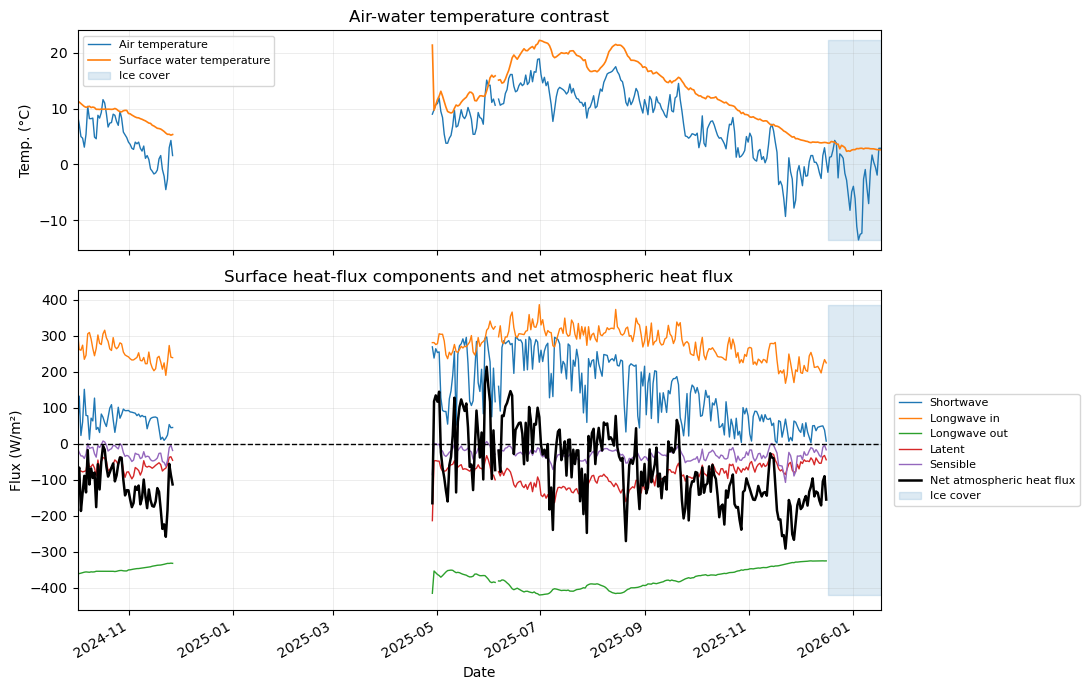

In [23]:
### Plot heat fluxes with gaps preserved
### No points, only lines
### Missing periods stay empty
### Ice cover shown as blue shading


if "flux" not in globals():
    raise ValueError("Run the flux computation cell first.")

# ── Build plotting dataframe on the full time axis ──────────────────────────
# Keep the full index so NaNs create real visual gaps.

flux_plot = flux.copy()

# For the temperature panel:
# only show air temperature where surface water temperature exists,
# so both series break over the same missing periods.
flux_plot["Tair_plot"] = flux_plot["Tair_C"].where(flux_plot["Twater_C"].notna())
flux_plot["Twater_plot"] = flux_plot["Twater_C"]

# For the flux panel:
# only show open-water values.
# During ice cover, keep NaN so the line disappears, but shading remains.
component_cols = [
    "SW_flux",
    "LW_in_flux",
    "LW_out_flux",
    "H_latent",
    "H_sensible",
    "H_net"
]

for col in component_cols:
    flux_plot[col + "_plot"] = flux_plot[col]

    if "ice_cover" in flux_plot.columns:
        flux_plot.loc[flux_plot["ice_cover"] == True, col + "_plot"] = np.nan

# ── Determine the real plotting window ──────────────────────────────────────
# Stop at the last date where either temperature or flux exists.

valid_any_temp = flux_plot[["Tair_plot", "Twater_plot"]].notna().any(axis=1)
valid_any_flux = flux_plot[[c + "_plot" for c in component_cols]].notna().any(axis=1)

valid_any = valid_any_temp | valid_any_flux

if not valid_any.any():
    raise ValueError("No valid data available for plotting.")

plot_start = flux_plot.index[valid_any].min()
plot_end = flux_plot.index[valid_any].max()

print("Plotting window:")
print("  start:", plot_start)
print("  end  :", plot_end)


# ── Create figure ────────────────────────────────────────────────────────────

fig_flux, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1.1, 1.6]}
)

# ── 1. Temperature panel ────────────────────────────────────────────────────
# Plot lines only. NaNs create empty gaps automatically.

axes[0].plot(
    flux_plot.index,
    flux_plot["Tair_plot"],
    linewidth=1.0,
    label="Air temperature"
)

axes[0].plot(
    flux_plot.index,
    flux_plot["Twater_plot"],
    linewidth=1.2,
    label="Surface water temperature"
)

if "ice_cover" in flux_plot.columns:

    ymin_temp = np.nanmin([
        flux_plot["Tair_plot"].min(),
        flux_plot["Twater_plot"].min()
    ])
    ymax_temp = np.nanmax([
        flux_plot["Tair_plot"].max(),
        flux_plot["Twater_plot"].max()
    ])

    axes[0].fill_between(
        flux_plot.index,
        ymin_temp,
        ymax_temp,
        where=(flux_plot["ice_cover"] == True),
        color="tab:blue",
        alpha=0.15,
        label="Ice cover"
    )

axes[0].set_ylabel("Temp. (°C)")
axes[0].set_title("Air-water temperature contrast")
axes[0].legend(fontsize=8, loc="best")
axes[0].grid(True, linewidth=0.4, alpha=0.4)


# ── 2. Flux panel ───────────────────────────────────────────────────────────
# Again, plot on full index with NaNs, so the gaps stay empty.

component_labels = {
    "SW_flux": "Shortwave",
    "LW_in_flux": "Longwave in",
    "LW_out_flux": "Longwave out",
    "H_latent": "Latent",
    "H_sensible": "Sensible",
    "H_net": "Net atmospheric heat flux"
}

for col in ["SW_flux", "LW_in_flux", "LW_out_flux", "H_latent", "H_sensible"]:
    axes[1].plot(
        flux_plot.index,
        flux_plot[col + "_plot"],
        linewidth=1.0,
        label=component_labels[col]
    )

axes[1].plot(
    flux_plot.index,
    flux_plot["H_net_plot"],
    color="k",
    linewidth=1.8,
    label=component_labels["H_net"]
)

if "ice_cover" in flux_plot.columns:

    flux_values = flux_plot[[c + "_plot" for c in component_cols]].to_numpy()

    flux_ymin = np.nanmin(flux_values)
    flux_ymax = np.nanmax(flux_values)

    axes[1].fill_between(
        flux_plot.index,
        flux_ymin,
        flux_ymax,
        where=(flux_plot["ice_cover"] == True),
        color="tab:blue",
        alpha=0.15,
        label="Ice cover"
    )

axes[1].axhline(
    0,
    linestyle="--",
    color="k",
    linewidth=1
)

axes[1].set_ylabel("Flux (W/m²)")
axes[1].set_xlabel("Date")
axes[1].set_title("Surface heat-flux components and net atmospheric heat flux")
axes[1].legend(
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5)
)
axes[1].grid(True, linewidth=0.4, alpha=0.4)


# ── Apply real data limits ──────────────────────────────────────────────────

axes[0].set_xlim(plot_start, plot_end)
axes[1].set_xlim(plot_start, plot_end)

fig_flux.autofmt_xdate()
fig_flux.tight_layout()


## 5. Export useful tables and figures

In [24]:
summary = {
    "selected_2026_option": selected_2026_option,
    "use_minidot_as_bottom": use_minidot_as_bottom,
    "common_surface_depth_m": depth_common[0],
    "common_bottom_depth_m": depth_common[-1],
    "strat_threshold_degC": strat_threshold,
    "strat_min_hours": strat_min_hours,
    "stratified_days": strat_days,
    "ice_on_threshold_degC": ice_on_threshold,
    "ice_off_threshold_degC": ice_off_threshold,
    "ice_min_on_hours": ice_min_on_hours,
    "ice_min_off_hours": ice_min_off_hours,
    "ice_days": ice_days,
    "thermocline_min_abs_gradient_C_m": thermocline_min_abs_gradient_C_m,
    "thermocline_smoothing_hours": thermocline_smoothing_hours,
    "thermocline_valid_points": int(np.isfinite(thermocline_depth_m).sum()),
    "median_thermocline_depth_m": np.nanmedian(thermocline_depth_m),
    "mean_thermocline_depth_m": np.nanmean(thermocline_depth_m),
    "median_thermocline_abs_gradient_C_m": np.nanmedian(
        np.abs(thermocline_gradient_C_m)
    ),
}

summary_df = pd.DataFrame([summary])
summary_df


,selected_2026_option,use_minidot_as_bottom,common_surface_depth_m,common_bottom_depth_m,strat_threshold_degC,strat_min_hours,stratified_days,ice_on_threshold_degC,ice_off_threshold_degC,ice_min_on_hours,ice_min_off_hours,ice_days,thermocline_min_abs_gradient_C_m,thermocline_smoothing_hours,thermocline_valid_points,median_thermocline_depth_m,mean_thermocline_depth_m,median_thermocline_abs_gradient_C_m
0,chainA,True,0.7,25.0,1.0,48,413.8125,0.1,0.0,48,48,32.541667,0.05,24,59589,5.3,9.215959,0.766401


In [25]:
import os, time, shutil, tempfile

output_dir = os.path.abspath("Figures")
os.makedirs(output_dir, exist_ok=True)
staging = tempfile.mkdtemp(prefix="taney_fig_")   # disque local rapide
print("output_dir:", output_dir)
print("staging   :", staging)

figures_to_export = {
    "01_raw_sensor_temperature": "fig1",
    "02_temperature_grid": "fig",
    "03_stratification": "fig3",
    "04_ice_cover": "fig_ice",
    "05_thermocline_depth": "fig_thermocline",
    "06_thermal_states_oxygen": "fig_mix",
    "07_heat_flux": "fig_flux",
    "08_heat_storage_residual": "fig_storage_residual",
}

def rasterize_heavy(fig, threshold=2000):
    for ax in fig.get_axes():
        for line in ax.get_lines():
            xd = line.get_xdata()
            if xd is not None and len(xd) > threshold:
                line.set_rasterized(True)
        for coll in ax.collections:      # pcolormesh, scatter...
            coll.set_rasterized(True)

for file_stem, figure_name in figures_to_export.items():
    if figure_name not in globals():
        print("Skipped:", file_stem, "| missing figure:", figure_name)
        continue
    figure_object = globals()[figure_name]
    rasterize_heavy(figure_object)

    t0 = time.perf_counter()
    for ext in ("png", "pdf"):
        local_path = os.path.join(staging, f"{file_stem}.{ext}")
        figure_object.savefig(local_path, dpi=300, bbox_inches="tight")   # LOCAL
        try:
            shutil.copy2(local_path, os.path.join(output_dir, f"{file_stem}.{ext}"))
        except (TimeoutError, OSError) as e:
            print(f"  /!\\ copie {ext} echouee: {e} -> reste en local: {local_path}")
    print("Exported: {:35s} ({:.1f} s)".format(file_stem, time.perf_counter() - t0))

print("\nStaging local:", staging)
print("Dossier figures:", output_dir)

output_dir: /Users/estelle/Documents/GitHub/taney-monitoring-masterfieldcamp/notebooks/Figures
staging   : /var/folders/4_/19fh9gx144j13yhqsvqk_vcw0000gn/T/taney_fig_regiz3ao
Exported: 01_raw_sensor_temperature           (2.6 s)
Exported: 02_temperature_grid                 (38.9 s)
Exported: 03_stratification                   (2.1 s)
Exported: 04_ice_cover                        (1.0 s)
Exported: 05_thermocline_depth                (1.5 s)
Exported: 06_thermal_states_oxygen            (1.4 s)
Exported: 07_heat_flux                        (0.7 s)
Skipped: 08_heat_storage_residual | missing figure: fig_storage_residual

Staging local: /var/folders/4_/19fh9gx144j13yhqsvqk_vcw0000gn/T/taney_fig_regiz3ao
Dossier figures: /Users/estelle/Documents/GitHub/taney-monitoring-masterfieldcamp/notebooks/Figures


,start,end,mean_H_net_W_m2,min_H_net_W_m2,max_H_net_W_m2,total_net_energy_MJ_m2
0,2025-07-25 12:00:00,2025-07-29 12:00:00,-115.257772,-247.669363,21.439088,-49.791358


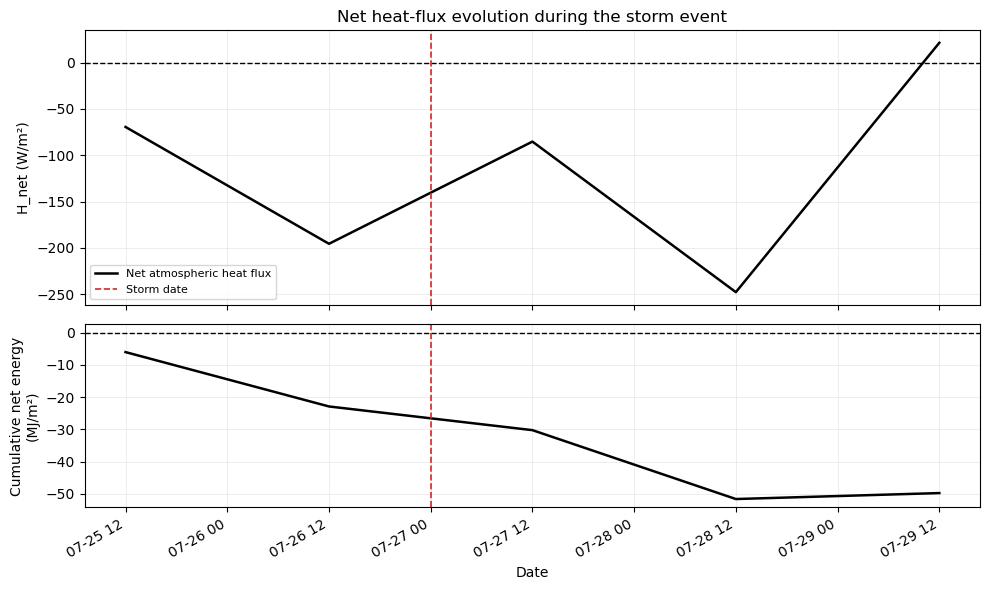

In [26]:
# Storm-event net heat flux
# Positive H_net = heat gain by the lake
# Negative H_net = heat loss from the lake

storm_date = "2025-07-27"   # change year if needed
window_before_days = 2
window_after_days = 3

storm_start = pd.to_datetime(storm_date) - pd.Timedelta(days=window_before_days)
storm_end = pd.to_datetime(storm_date) + pd.Timedelta(days=window_after_days)

storm_flux = flux_plot.loc[
    (flux_plot.index >= storm_start)
    & (flux_plot.index <= storm_end)
].copy()


if storm_flux.empty:
    raise ValueError("No heat-flux data found in the selected storm window.")

# Cumulative net energy per m2 during the event window.
# H_net is W/m2 = J/s/m2, so multiply by time step in seconds.

storm_flux["dt_seconds"] = storm_flux.index.to_series().diff().dt.total_seconds()
storm_flux["dt_seconds"] = storm_flux["dt_seconds"].fillna(
    storm_flux["dt_seconds"].median()
)

storm_flux["H_net_energy_J_m2"] = (
    storm_flux["H_net_plot"] * storm_flux["dt_seconds"]
)

storm_flux["H_net_cumulative_MJ_m2"] = (
    storm_flux["H_net_energy_J_m2"].cumsum() / 1e6
)

storm_summary = pd.DataFrame(
    {
        "start": [storm_flux.index.min()],
        "end": [storm_flux.index.max()],
        "mean_H_net_W_m2": [storm_flux["H_net_plot"].mean()],
        "min_H_net_W_m2": [storm_flux["H_net_plot"].min()],
        "max_H_net_W_m2": [storm_flux["H_net_plot"].max()],
        "total_net_energy_MJ_m2": [storm_flux["H_net_energy_J_m2"].sum() / 1e6],
    }
)

display(storm_summary)


# Plot storm evolution

fig_storm_flux, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1.5, 1]}
)

axes[0].plot(
    storm_flux.index,
    storm_flux["H_net_plot"],
    color="k",
    linewidth=1.8,
    label="Net atmospheric heat flux"
)

axes[0].axhline(
    0,
    color="k",
    linestyle="--",
    linewidth=1
)

axes[0].axvline(
    pd.to_datetime(storm_date),
    color="tab:red",
    linestyle="--",
    linewidth=1.2,
    label="Storm date"
)

axes[0].set_ylabel("H_net (W/m²)")
axes[0].set_title("Net heat-flux evolution during the storm event")
axes[0].legend(fontsize=8)
axes[0].grid(True, linewidth=0.4, alpha=0.4)


axes[1].plot(
    storm_flux.index,
    storm_flux["H_net_cumulative_MJ_m2"],
    color="k",
    linewidth=1.8
)

axes[1].axhline(
    0,
    color="k",
    linestyle="--",
    linewidth=1
)

axes[1].axvline(
    pd.to_datetime(storm_date),
    color="tab:red",
    linestyle="--",
    linewidth=1.2
)

axes[1].set_ylabel("Cumulative net energy\n(MJ/m²)")
axes[1].set_xlabel("Date")
axes[1].grid(True, linewidth=0.4, alpha=0.4)

fig_storm_flux.autofmt_xdate()
fig_storm_flux.tight_layout()

## 4.9 Dynamic thermal structure 2025–2026

Full-resolution heatmap for the 2025–2026 campaign using a dynamic depth model for chain B.
Chain B depths are corrected with water-level data up to 2026-01-18, then inferred from the chain A temperature profile (T-inversion). Ice-cover period (2025-12-16 → 2026-04-11): last valid depth is carried forward.
The uncertain deep zone (z > 12.53 m, after 2026-01-18) is displayed at reduced opacity. The MiniDOT sensor is tracked as a cyan dotted line.

Edit the **CONFIGURATION** cell below to adapt paths and parameters.

In [27]:
# ===========================================================================
# CONFIGURATION  —  Section 4.9 · Dynamic thermal structure 2025–2026
# Edit ONLY this cell to adapt paths for a new deployment.
# ===========================================================================

# Campaign identifier (must match the folder name in data/Mooring/)
_dyn_CAMPAIGN = "20260603"

# ── Thermistor Level2 files (one .nc per sensor, produced by main_mooring.py)
_dyn_L2_DIR = os.path.join(
    data_folder_hobo,
    _dyn_CAMPAIGN,
    "Level2"
)

# ── Water-level variation CSV
# Canonical location: data/Mooring/HOBO_P/<campaign>/Level2/water_level_variation.csv
# Produced by the HOBO_P pressure pipeline.
# Format: columns  date | time | delta_wl
#   - timestamps are UTC (GMT+00:00)
#   - delta_wl in metres, variation around an arbitrary reference level
#   - _dyn_load_water_level() resets the zero to the deployment time automatically
_dyn_WL_CSV = os.path.join(
    data_folder_hobo.replace("HOBO_T", "HOBO_P"),
    _dyn_CAMPAIGN,
    "Level2",
    "water_level_variation.csv"
)

# ── MiniDOT Cat.TXT  (concatenated raw export from the miniDOT Logger app)
# Serial number sub-folder: adjust "7450-583960" if the logger changes.
_dyn_MINIDOT_TXT = os.path.join(
    data_folder_minidot,
    _dyn_CAMPAIGN,
    "Level0",
    "7450-583960",
    "Cat.TXT"
)

# ── Deployment time (naive local civil time — heure civile locale)
_dyn_DEPLOY_LOCAL = "2025-06-06 10:39:00"

# ── Chain B nominal depths at deployment [m from surface]  —  from .meta
_dyn_DEPTH_B_NOMINAL = {
    "Sensor_Number_2": 15.6,
    "Sensor_Number_3": 13.5,
}

# ── MiniDOT is always this many metres BELOW S2 on the same rope
_dyn_DEPTH_MINIDOT_OFFSET = 14.0   # m

# ── Interpolation / display grid
_dyn_Z_MAX   = 35.0   # m  (display cap — not the physical lake depth)
_dyn_DZ_GRID = 0.1    # m

# ── Colourmap
_dyn_CMAP = "plasma"

# ── Ice-cover window (local civil time, inclusive)
# Source: field observations Lake Taney 2025-2026.
_dyn_ICE_COVER_START = "2025-12-16"
_dyn_ICE_COVER_END   = "2026-04-11"

# ── Smoothing of the uncertain deep zone (z > 12.53 m) after water-level
#    data ends (~2026-01-18). Chain A zone is NEVER smoothed.
_dyn_SMOOTH_WINDOW_DAYS = 1   # days

# ── Deepest chain A sensor — boundary between certain / uncertain zones
_dyn_DEPTH_CHAIN_A_DEEPEST = 12.53   # m  (S4, Sensor_Number_4)

# ── Hard existence checks — crash immediately with a useful message
if not os.path.isdir(_dyn_L2_DIR):
    raise FileNotFoundError(
        "Thermistor Level2 folder not found: {}\n"
        "  -> Run main_mooring.py for campaign {} first, or copy Level2 from SwitchDrive:\n"
        "     data/Mooring/HOBO_T/{}/Level2/".format(
            _dyn_L2_DIR, _dyn_CAMPAIGN, _dyn_CAMPAIGN)
    )

if not os.path.isfile(_dyn_WL_CSV):
    raise FileNotFoundError(
        "water_level_variation.csv not found: {}\n"
        "  -> Copy from SwitchDrive: data/Mooring/HOBO_P/{}/Level2/water_level_variation.csv".format(
            _dyn_WL_CSV, _dyn_CAMPAIGN)
    )

if not os.path.isfile(_dyn_MINIDOT_TXT):
    raise FileNotFoundError(
        "MiniDOT Cat.TXT not found: {}\n"
        "  -> Copy from SwitchDrive: data/Mooring/miniDOT/{}/Level0/7450-583960/Cat.TXT".format(
            _dyn_MINIDOT_TXT, _dyn_CAMPAIGN)
    )

print("Configuration loaded — all input files found.")
print("  L2 dir      : {}".format(_dyn_L2_DIR))
print("  WL csv      : {}".format(_dyn_WL_CSV))
print("  MiniDOT txt : {}".format(_dyn_MINIDOT_TXT))


Configuration loaded — all input files found.
  L2 dir      : ../data/Mooring/HOBO_T/20260603/Level2
  WL csv      : ../data/Mooring/HOBO_P/20260603/Level2/water_level_variation.csv
  MiniDOT txt : ../data/Mooring/miniDOT/20260603/Level0/7450-583960/Cat.TXT


In [28]:
# ===========================================================================
# Helper functions — dynamic thermal structure 2025-2026
# All names prefixed _dyn_ to avoid collision with the notebook namespace.
# ===========================================================================

import matplotlib.colors as _mcolors
import matplotlib.patheffects as _pe
import datetime as _dt_module


def _dyn_load_thermistor_l2(l2_dir):
    """Load all thermistor L2 netCDF files.

    Parameters
    ----------
    l2_dir : str
        Directory containing L2_mooring_csv_T_Sensor_Number_*.nc files.

    Returns
    -------
    list of dict
        Keys: sensor, depth_nominal, chain, time_epoch [POSIX s, naive local],
              temp [°C, NaN where masked].
    """
    pattern = "L2_mooring_csv_T_Sensor_Number_"
    files = sorted(
        f for f in os.listdir(l2_dir)
        if f.startswith(pattern) and f.endswith(".nc")
    )
    if not files:
        raise FileNotFoundError(f"No '{pattern}*.nc' in {l2_dir}")

    sensors = []
    for fname in files:
        fpath = os.path.join(l2_dir, fname)
        nc    = netCDF4.Dataset(fpath)
        base  = fname.replace(".nc", "")
        parts = base.split("_")
        idx   = parts.index("Sensor")
        sensor_name = "_".join(parts[idx: idx + 3])
        depth_nominal = float(getattr(nc, "Depth (m)"))
        chain = "B" if sensor_name in _dyn_DEPTH_B_NOMINAL else "A"
        t_raw    = nc.variables["time"][:].data.astype(np.float64)
        temp_raw = nc.variables["Temp"][:]
        mask     = temp_raw.mask if hasattr(temp_raw, "mask") else np.zeros(len(t_raw), bool)
        temp     = np.where(mask, np.nan, temp_raw.data.astype(np.float64))
        nc.close()
        sensors.append(dict(
            sensor        = sensor_name,
            depth_nominal = depth_nominal,
            chain         = chain,
            time_epoch    = t_raw,
            temp          = temp,
        ))
        print(f"  {sensor_name}: chain={chain}, depth={depth_nominal} m, n={len(t_raw)}")
    return sensors


def _dyn_load_minidot(txt_path, depth_s2_nominal):
    """Load MiniDOT Cat.TXT. UTC timestamps converted to naive local wall-clock.

    Parameters
    ----------
    txt_path : str
    depth_s2_nominal : float  Nominal depth of S2 at deployment [m from surface].

    Returns
    -------
    dict  sensor='MiniDOT', chain='B', time_epoch [POSIX naive local], temp [°C].
    """
    from datetime import timezone as _tz
    df = pd.read_csv(
        txt_path,
        skiprows  = 9,
        header    = None,
        names     = ["unix_ts", "utc_dt1", "utc_dt2",
                     "battery", "temp_C", "do_mgl", "do_sat", "Q"],
        skipinitialspace = True,
    )
    df = df.dropna(subset=["unix_ts"])
    df["unix_ts"] = pd.to_numeric(df["unix_ts"], errors="coerce")
    df = df.dropna(subset=["unix_ts"])
    df["temp_C"] = pd.to_numeric(df["temp_C"], errors="coerce")
    dt_utc      = pd.to_datetime(df["unix_ts"], unit="s", utc=True)
    dt_local    = dt_utc.dt.tz_convert("Europe/Zurich").dt.tz_localize(None)
    epoch_local = dt_local.values.astype("datetime64[ns]").astype(np.int64) / 1e9
    depth_nominal = depth_s2_nominal + _dyn_DEPTH_MINIDOT_OFFSET
    print(f"  MiniDOT: chain=B, depth_nominal={depth_nominal} m, n={len(df)}")
    return dict(
        sensor        = "MiniDOT",
        depth_nominal = depth_nominal,
        chain         = "B",
        time_epoch    = epoch_local,
        temp          = df["temp_C"].values.astype(np.float64),
    )


def _dyn_load_water_level(wl_csv, deployment_time_local):
    """Load water_level_variation.csv rebased so delta_wl = 0 at deployment.

    Parameters
    ----------
    wl_csv : str  Columns: date, time, delta_wl. Timestamps are genuine UTC.
    deployment_time_local : str  Naive local wall-clock, e.g. '2025-06-06 10:39:00'.

    Returns
    -------
    pandas.Series  Index = POSIX s (naive local), values = delta_wl [m].
    """
    df     = pd.read_csv(wl_csv)
    dt_utc = pd.to_datetime(df["date"] + " " + df["time"]).dt.tz_localize("UTC")
    dt_loc = dt_utc.dt.tz_convert("Europe/Zurich").dt.tz_localize(None)
    epoch  = dt_loc.values.astype("datetime64[ns]").astype(np.int64) / 1e9
    wl     = pd.Series(df["delta_wl"].values, index=epoch).sort_index()
    deploy_epoch = pd.Timestamp(deployment_time_local).value / 1e9
    offset = np.interp(deploy_epoch, wl.index.values, wl.values)
    wl -= offset
    print(f"  WL: {len(wl)} pts | rebased range: [{wl.min():.3f}, {wl.max():.3f}] m")
    return wl


def _dyn_resample_to_hourly(sensors, wl):
    """Resample sensors + water level to a common 1-hour grid.

    Returns
    -------
    common_time   : np.ndarray  POSIX seconds (n_time,)
    sensor_hourly : list of dict  with hourly temp/time_epoch arrays
    wl_hourly     : np.ndarray  delta_wl [m], NaN outside wl coverage
    """
    t_start_all = max(s['time_epoch'][0]  for s in sensors)
    t_end_all   = min(s['time_epoch'][-1] for s in sensors)
    t_start_h   = np.ceil(t_start_all  / 3600) * 3600
    t_end_h     = np.floor(t_end_all   / 3600) * 3600
    common_time = np.arange(t_start_h, t_end_h + 1, 3600, dtype=np.float64)
    print(f"  Common hourly grid: {len(common_time)} steps")
    common_dt = pd.to_datetime(common_time, unit="s", origin="unix")
    sensor_hourly = []
    for s in sensors:
        dt_idx = pd.to_datetime(s['time_epoch'], unit='s', origin='unix')
        ts     = pd.Series(s['temp'], index=dt_idx)
        ts_h   = ts.resample('1h').mean().reindex(common_dt)
        out = dict(s)
        out['time_epoch'] = common_time
        out['temp']       = ts_h.values.astype(np.float64)
        sensor_hourly.append(out)
    wl_hourly = np.interp(
        common_time, wl.index.values, wl.values,
        left=np.nan, right=np.nan,
    )
    return common_time, sensor_hourly, wl_hourly


_dyn_MIXED_THRESHOLD = 0.5   # °C


def _dyn_invert_T_to_depth(T_target, zs_A, Ts_A):
    """Depth at which chain A temperature profile equals T_target.

    IN-RANGE: np.interp on (T,z) sorted by T ascending.
    OUT-OF-RANGE BELOW: linear extrapolation from two deepest chain A sensors.
    Returns NaN if gradient < 0.05 °C/m or extrapolation lands above S4.
    """
    T_min, T_max = Ts_A.min(), Ts_A.max()
    if T_min <= T_target <= T_max:
        order = np.argsort(Ts_A)
        return float(np.interp(T_target, Ts_A[order], zs_A[order]))
    z_deep1, z_deep2 = zs_A[-2], zs_A[-1]
    T_deep1, T_deep2 = Ts_A[-2], Ts_A[-1]
    dz = z_deep2 - z_deep1
    dT = T_deep2 - T_deep1
    if abs(dT) < 0.05:
        return np.nan
    slope    = dT / dz
    z_extrap = z_deep2 + (T_target - T_deep2) / slope
    if z_extrap <= z_deep2:
        return np.nan
    return float(z_extrap)


def _dyn_build_temp_grid(common_time, sensor_hourly, wl_hourly):
    """Build 2-D temperature grid (n_time × n_depth).

    Chain A: fixed depths. Chain B: geometric correction while water-level
    data is available, then T-inversion on chain A. MiniDOT = S2 + offset.
    Ice period: carry-forward. Gap bridging: 48-h linear bridge at ice-out.
    """
    depth_grid = np.arange(0.0, _dyn_Z_MAX + _dyn_DZ_GRID / 2, _dyn_DZ_GRID)
    n_time     = len(common_time)
    n_depth    = len(depth_grid)
    temp_grid  = np.full((n_time, n_depth), np.nan)

    sensors_A = [s for s in sensor_hourly if s['chain'] == 'A']
    sensors_B = [s for s in sensor_hourly if s['chain'] == 'B']
    order_A   = np.argsort([s['depth_nominal'] for s in sensors_A])
    sensors_A = [sensors_A[k] for k in order_A]
    zA_fixed  = np.array([s['depth_nominal'] for s in sensors_A])

    chain_b_depths = {s['sensor']: np.full(n_time, np.nan) for s in sensors_B}
    last_valid_z   = {s['sensor']: np.nan  for s in sensors_B}
    gap_start      = {s['sensor']: None    for s in sensors_B}
    gap_start_z    = {s['sensor']: np.nan  for s in sensors_B}

    ice_start  = _dt_module.datetime.strptime(_dyn_ICE_COVER_START, '%Y-%m-%d')
    ice_end    = _dt_module.datetime.strptime(_dyn_ICE_COVER_END, '%Y-%m-%d').replace(
                     hour=23, minute=59, second=59)
    BRIDGE_CAP         = 48
    S2S3_GAP           = 2.1
    S2S3_HALF          = 1.05

    for i in range(n_time):
        TA      = np.array([s['temp'][i] for s in sensors_A])
        valid_A = ~np.isnan(TA)
        if valid_A.sum() < 2:
            continue
        zA    = zA_fixed[valid_A]
        TA    = TA[valid_A]
        mixed = (TA.max() - TA.min()) < _dyn_MIXED_THRESHOLD
        t_local = _dt_module.datetime(1970, 1, 1) + _dt_module.timedelta(
                      seconds=float(common_time[i]))
        under_ice = ice_start <= t_local <= ice_end

        for s in sensors_B:
            sname      = s['sensor']
            is_minidot = sname == 'MiniDOT'
            T_B        = s['temp'][i]
            if np.isnan(T_B):
                chain_b_depths[sname][i] = last_valid_z[sname]
                continue
            delta = wl_hourly[i]
            if not np.isnan(delta):
                z_B = s['depth_nominal'] + delta
                chain_b_depths[sname][i] = z_B
                last_valid_z[sname]       = z_B
                gap_start[sname]          = None
            elif is_minidot:
                chain_b_depths[sname][i] = np.nan
            else:
                if mixed or under_ice:
                    chain_b_depths[sname][i] = last_valid_z[sname]
                    if gap_start[sname] is None:
                        gap_start[sname]   = i
                        gap_start_z[sname] = last_valid_z[sname]
                else:
                    z_inferred = _dyn_invert_T_to_depth(T_B, zA, TA)
                    if np.isnan(z_inferred):
                        if gap_start[sname] is None:
                            gap_start[sname]   = i
                            gap_start_z[sname] = last_valid_z[sname]
                        chain_b_depths[sname][i] = np.nan
                    else:
                        if gap_start[sname] is not None:
                            future_vals = []
                            for j in range(i, min(i + 72, n_time)):
                                T_fut  = s['temp'][j]
                                if np.isnan(T_fut): continue
                                TA_fut = np.array([sa['temp'][j] for sa in sensors_A])
                                v_fut  = ~np.isnan(TA_fut)
                                if v_fut.sum() < 2: continue
                                z_fut = _dyn_invert_T_to_depth(
                                    T_fut, zA_fixed[v_fut], TA_fut[v_fut])
                                if not np.isnan(z_fut):
                                    future_vals.append(z_fut)
                                if len(future_vals) >= 72: break
                            z_target = float(np.mean(future_vals)) if future_vals else z_inferred
                            i0      = gap_start[sname]
                            z0      = gap_start_z[sname]
                            gap_len = i - i0
                            if gap_len > BRIDGE_CAP:
                                bridge_start = max(i0, i - BRIDGE_CAP)
                                bridge_len   = i - bridge_start
                                if bridge_len > 0 and not np.isnan(z0):
                                    bridge = np.linspace(z0, z_target, bridge_len + 1)
                                    chain_b_depths[sname][bridge_start: i + 1] = bridge
                            else:
                                if gap_len > 0 and not np.isnan(z0):
                                    bridge = np.linspace(z0, z_target, gap_len + 1)
                                    chain_b_depths[sname][i0: i + 1] = bridge
                            gap_start[sname] = None
                        chain_b_depths[sname][i] = z_inferred
                        last_valid_z[sname]       = z_inferred

        z_s3 = chain_b_depths['Sensor_Number_3'][i]
        z_s2 = chain_b_depths['Sensor_Number_2'][i]
        if not np.isnan(z_s3) and not np.isnan(z_s2):
            if abs(z_s2 - z_s3 - S2S3_GAP) > 0.01:
                mid = (z_s2 + z_s3) / 2.0
                chain_b_depths['Sensor_Number_3'][i] = mid - S2S3_HALF
                chain_b_depths['Sensor_Number_2'][i] = mid + S2S3_HALF
                last_valid_z['Sensor_Number_3']       = mid - S2S3_HALF
                last_valid_z['Sensor_Number_2']       = mid + S2S3_HALF

        z_s2_now = chain_b_depths['Sensor_Number_2'][i]
        if np.isnan(chain_b_depths['MiniDOT'][i]):
            if not np.isnan(z_s2_now):
                z_md = z_s2_now + _dyn_DEPTH_MINIDOT_OFFSET
                chain_b_depths['MiniDOT'][i] = z_md
                last_valid_z['MiniDOT']       = z_md
            else:
                chain_b_depths['MiniDOT'][i] = last_valid_z['MiniDOT']

        depths_i = list(zA)
        temps_i  = list(TA)
        for s in sensors_B:
            T_B = s['temp'][i]
            z_B = chain_b_depths[s['sensor']][i]
            if not np.isnan(T_B) and not np.isnan(z_B):
                depths_i.append(z_B)
                temps_i.append(T_B)
        if len(depths_i) < 2: continue
        order = np.argsort(depths_i)
        zs    = np.array(depths_i)[order]
        Ts    = np.array(temps_i)[order]
        _, uid = np.unique(zs, return_index=True)
        zs, Ts = zs[uid], Ts[uid]
        if len(zs) < 2: continue
        in_range = (depth_grid >= zs[0]) & (depth_grid <= zs[-1])
        temp_grid[i, in_range] = np.interp(depth_grid[in_range], zs, Ts)

    # Post-loop: enforce S2/S3 = 2.1 m gap across the full series
    z_s2_arr   = chain_b_depths['Sensor_Number_2']
    z_s3_arr   = chain_b_depths['Sensor_Number_3']
    both_v     = ~np.isnan(z_s2_arr) & ~np.isnan(z_s3_arr)
    violation  = both_v & (np.abs(z_s2_arr - z_s3_arr - S2S3_GAP) > 0.01)
    if violation.any():
        mid = (z_s2_arr[violation] + z_s3_arr[violation]) / 2.0
        chain_b_depths['Sensor_Number_3'][violation] = mid - S2S3_HALF
        chain_b_depths['Sensor_Number_2'][violation] = mid + S2S3_HALF
        chain_b_depths['MiniDOT'][violation] = (
            chain_b_depths['Sensor_Number_2'][violation] + _dyn_DEPTH_MINIDOT_OFFSET
        )
        print(f"  S2/S3 gap corrected at {violation.sum()} timesteps")
    n_valid = np.sum(~np.isnan(temp_grid))
    print(f"  Grid: {temp_grid.shape} | valid cells: {n_valid}/{temp_grid.size} "
          f"({100*n_valid/temp_grid.size:.1f}%)")
    return depth_grid, temp_grid, chain_b_depths


def _dyn_smooth_uncertain_period(temp_grid, wl_hourly, depth_grid):
    """Apply rolling mean to temp_grid after end of water-level data.

    Only depth cells below _dyn_DEPTH_CHAIN_A_DEEPEST (12.53 m) are smoothed.
    Chain A zone is always at full hourly resolution.
    """
    last_wl_idx  = np.where(~np.isnan(wl_hourly))[0][-1]
    window_steps = int(_dyn_SMOOTH_WINDOW_DAYS * 24)
    grid_out     = temp_grid.copy()
    if last_wl_idx >= len(wl_hourly) - 1:
        return grid_out
    deep_cols = np.where(depth_grid > _dyn_DEPTH_CHAIN_A_DEEPEST)[0]
    if len(deep_cols) == 0:
        return grid_out
    uncertain_slice = pd.DataFrame(temp_grid[last_wl_idx:, :][:, deep_cols])
    smoothed = uncertain_slice.rolling(
        window=window_steps, min_periods=1, center=True).mean()
    grid_out[last_wl_idx:, deep_cols] = smoothed.values
    n_smoothed = len(wl_hourly) - last_wl_idx
    print(f"  Smoothed {n_smoothed} timesteps × {len(deep_cols)} depth cells "
          f"(z > {_dyn_DEPTH_CHAIN_A_DEEPEST} m) "
          f"with {_dyn_SMOOTH_WINDOW_DAYS}-day rolling mean")
    return grid_out


def _dyn_epoch_to_dt64(epoch_array):
    """POSIX seconds (naive local) -> datetime64[ms] for matplotlib."""
    return (epoch_array * 1e3).astype("datetime64[ms]")


def _dyn_apply_date_formatter(ax):
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))


def _dyn_plot_heatmap(common_time, depth_grid, temp_grid,
                      sensor_hourly, wl_hourly, chain_b_depths):
    """Heatmap x=time, y=depth, colour=temperature with sensor trajectories.

    Chain A   : solid white lines at fixed depths.
    Chain B   : dashed white lines (geometric and physics-derived periods).
    MiniDOT   : cyan dotted line.
    Grey band : uncertain deep zone (z > 12.53 m) after water-level data ends.
    Green star: terrain MiniDOT retrieval depth (field measurement, 32.8 m).
    """
    time_dt     = _dyn_epoch_to_dt64(common_time)
    last_wl_idx = np.where(~np.isnan(wl_hourly))[0][-1]
    fig, ax = plt.subplots(figsize=(14, 8))
    norm = _mcolors.Normalize(vmin=np.nanmin(temp_grid), vmax=np.nanmax(temp_grid))
    pcm  = ax.pcolormesh(
        time_dt, depth_grid, temp_grid.T,
        cmap=_dyn_CMAP, norm=norm, shading='auto', rasterized=True,
    )

    # Semi-transparent grey overlay on uncertain deep zone
    if last_wl_idx < len(time_dt) - 1:
        deep_mask = depth_grid > _dyn_DEPTH_CHAIN_A_DEEPEST
        overlay   = np.ones((len(time_dt) - last_wl_idx, deep_mask.sum()))
        ax.pcolormesh(
            time_dt[last_wl_idx:], depth_grid[deep_mask], overlay.T,
            cmap='Greys_r', vmin=0, vmax=1,
            shading='auto', alpha=0.40, rasterized=True, zorder=2,
        )

    # Chain A: solid white lines
    chain_a    = sorted([s for s in sensor_hourly if s['chain'] == 'A'],
                        key=lambda x: x['depth_nominal'])
    lbl_x_pos  = np.linspace(0.30, 0.60, len(chain_a))
    for i_lbl, s in enumerate(chain_a):
        snum   = s['sensor'].split('_')[-1]
        z_line = np.full(len(common_time), s['depth_nominal'])
        ax.plot(time_dt, z_line,
                color='white', linewidth=0.6, linestyle='-',
                alpha=0.55, rasterized=True, zorder=4)
        t_lbl = time_dt[int(lbl_x_pos[i_lbl] * len(time_dt))]
        ax.text(t_lbl, s['depth_nominal'] - 0.25,
                f'S{snum}', fontsize=6.5, color='white',
                va='bottom', ha='center', alpha=0.85, zorder=5,
                path_effects=[_pe.withStroke(linewidth=2, foreground='black', alpha=0.5)])

    # Chain B and MiniDOT: dashed white / cyan dotted
    for s in sorted(sensor_hourly, key=lambda x: x['depth_nominal']):
        if s['chain'] != 'B': continue
        sname      = s['sensor']
        is_minidot = sname == 'MiniDOT'
        snum       = sname.split('_')[-1] if not is_minidot else 'MiniDOT'
        z_display  = chain_b_depths[sname].copy()
        z_display[z_display > _dyn_Z_MAX] = np.nan
        col, ls, lw, al = ('cyan', ':', 1.0, 0.75) if is_minidot else ('white', '--', 0.7, 0.55)
        idx_arr   = np.arange(len(common_time))
        for mask in (~np.isnan(z_display) & (idx_arr <= last_wl_idx),
                     ~np.isnan(z_display) & (idx_arr >  last_wl_idx)):
            if mask.any():
                ax.plot(time_dt[mask], z_display[mask],
                        color=col, linewidth=lw, linestyle=ls,
                        alpha=al, rasterized=True, zorder=4)
        lbl_idx = int(0.65 * len(common_time))
        if not np.isnan(z_display[lbl_idx]):
            label = 'MiniDOT' if is_minidot else f'S{snum}'
            v_off, va = (0.25, 'top') if is_minidot else (-0.2, 'bottom')
            ax.text(time_dt[lbl_idx], z_display[lbl_idx] + v_off,
                    label, fontsize=6.5, color=col, va=va, ha='center',
                    alpha=0.9, zorder=5)

    # Transition line: end of water-level data
    ax.axvline(time_dt[last_wl_idx],
               color='yellow', linewidth=0.8, linestyle='--', alpha=0.6,
               label='End of water-level data\n→ chain B depth inferred from T')

    # Retrieval date vertical line
    last_data_dt = np.datetime64('2026-06-03T15:00', 'ms')
    ax.axvline(last_data_dt, color='white', linewidth=0.8, linestyle='--',
               alpha=0.5, zorder=4)
    ax.text(last_data_dt, 0.5, '  Last data\n  03 Jun 2026',
            fontsize=6.5, color='white', va='top', ha='left', alpha=0.9, zorder=5)

    # Terrain reference point: MiniDOT retrieval (field measurement)
    retrieval_dt = np.datetime64('2026-06-03T15:00', 'ms')
    retrieval_z  = 32.8   # m — field notes
    ax.scatter([retrieval_dt], [retrieval_z],
               color='lime', s=60, zorder=5, marker='*',
               label=f'MiniDOT retrieval depth (terrain): {retrieval_z} m')
    ax.annotate(
        f'{retrieval_z} m\n(terrain)',
        xy=(retrieval_dt, retrieval_z),
        xytext=(-60, 18), textcoords='offset points',
        fontsize=7, color='lime', va='bottom', ha='center',
        arrowprops=dict(arrowstyle='-', color='lime', lw=0.6), zorder=6,
    )

    cbar = fig.colorbar(pcm, ax=ax, pad=0.01, aspect=40)
    cbar.set_label('Temperature (°C)', fontsize=11)
    ax.invert_yaxis()
    ax.set_ylabel('Depth from surface (m)', fontsize=11)
    ax.set_xlabel('Date (local civil time)', fontsize=11)
    ax.set_title('Lake Taney — Thermal Structure 2025–2026', fontsize=12, loc='left')
    _dyn_apply_date_formatter(ax)
    ax.legend(fontsize=8, loc='lower left', framealpha=0.7)
    ax.grid(False)
    fig.tight_layout()
    return fig


def _dyn_plot_temp_series(sensor_hourly, common_time):
    """Temperature time series per sensor, coloured by nominal depth.

    Zoom window fixed to 2025-07-26 → 2025-07-30 to highlight summer
    stratification.
    """
    non_minidot = [s for s in sensor_hourly if s['sensor'] != 'MiniDOT']
    all_depths  = [s['depth_nominal'] for s in non_minidot]
    norm_d = _mcolors.Normalize(vmin=min(all_depths), vmax=max(all_depths))
    cmap_d = plt.get_cmap('viridis_r')
    fig, ax = plt.subplots(figsize=(14, 5))
    time_dt = _dyn_epoch_to_dt64(common_time)
    for s in sorted(non_minidot, key=lambda x: x['depth_nominal']):
        valid = ~np.isnan(s['temp'])
        color = cmap_d(norm_d(s['depth_nominal']))
        snum  = s['sensor'].split('_')[-1]
        lbl   = f"S{snum} ({'B*' if s['chain'] == 'B' else 'A'}) {s['depth_nominal']:.1f} m"
        ax.plot(time_dt[valid], s['temp'][valid],
                color=color, linewidth=1.5, label=lbl, rasterized=True)
        if valid.any():
            zoom_mid = np.datetime64('2025-07-29', 'ms')
            in_zoom  = valid & (time_dt <= zoom_mid)
            if in_zoom.any():
                idx = np.where(in_zoom)[0][-1]
                ax.text(time_dt[idx], s['temp'][idx], f'  S{snum}',
                        fontsize=7, color=color, va='top')
    sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=norm_d)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, aspect=35)
    cbar.set_label('Nominal depth (m)', fontsize=10)
    ax.set_ylabel('Temperature (°C)', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title('Lake Taney 2025–2026 — Temperature time series', fontsize=12, loc='left')
    ax.set_title('* = chain B', fontsize=8, loc='right', color='grey')
    _dyn_apply_date_formatter(ax)
    ax.set_ylim(7, 20)
    ax.set_xlim(np.datetime64('2025-07-26', 'ms'), np.datetime64('2025-07-30', 'ms'))
    ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.6)
    ax.legend(fontsize=7, ncol=2, loc='upper right', framealpha=0.7,
              title='Sensor / Chain / Depth')
    fig.tight_layout()
    return fig


print('Section 4.9 helper functions defined.')

Section 4.9 helper functions defined.


Loading thermistor L2 files ...
  Sensor_Number_10: chain=A, depth=0.7 m, n=52176
  Sensor_Number_2: chain=B, depth=15.6 m, n=52174
  Sensor_Number_3: chain=B, depth=13.5 m, n=52175
  Sensor_Number_4: chain=A, depth=12.53 m, n=52175
  Sensor_Number_5: chain=A, depth=10.01 m, n=52175
  Sensor_Number_6: chain=A, depth=7.6 m, n=52176
  Sensor_Number_7: chain=A, depth=5.62 m, n=52176
  Sensor_Number_8: chain=A, depth=3.62 m, n=52175
  Sensor_Number_9: chain=A, depth=1.62 m, n=52176
  -> 9 thermistors

Loading MiniDOT ...
  MiniDOT: chain=B, depth_nominal=29.6 m, n=521690

Loading water-level variation ...
  WL: 21669 pts | rebased range: [-4.505, 1.426] m

Resampling to 1-hour common grid ...
  Common hourly grid: 8694 steps

Building interpolated temperature grid ...
  S2/S3 gap corrected at 61 timesteps
  Grid: (8694, 351) | valid cells: 2321943/3051594 (76.1%)

Smoothing uncertain period ...
  Smoothed 3276 timesteps × 225 depth cells (z > 12.53 m) with 1-day rolling mean

Plotting ...


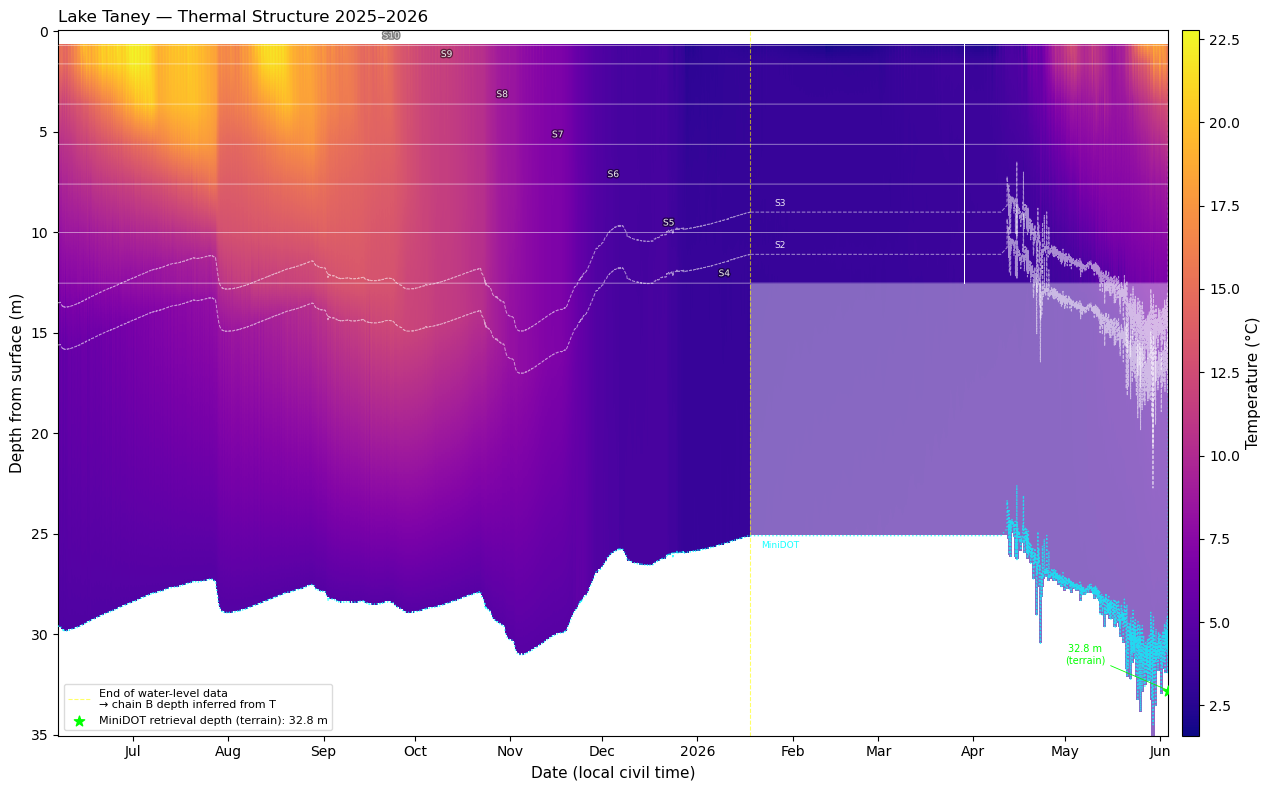

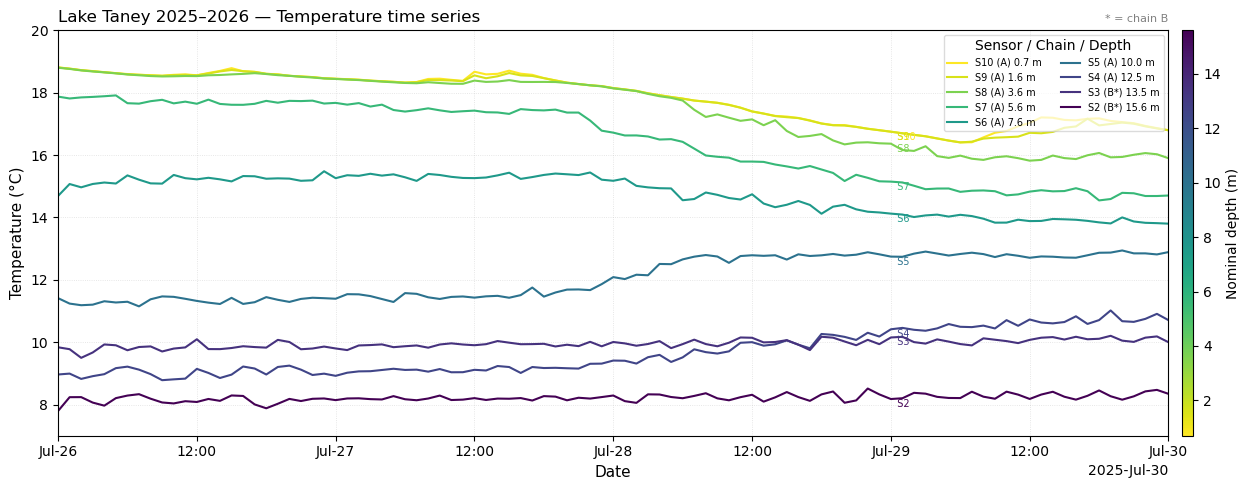

In [29]:
# ===========================================================================
# Run: load → resample → build grid → smooth → plot
# All inputs are guaranteed to exist by the configuration cell above.
# ===========================================================================

print("=" * 60)
print("Loading thermistor L2 files ...")
_dyn_sensors = _dyn_load_thermistor_l2(_dyn_L2_DIR)
print("  -> {} thermistors\n".format(len(_dyn_sensors)))

print("Loading MiniDOT ...")
_dyn_sensors.append(
    _dyn_load_minidot(_dyn_MINIDOT_TXT, _dyn_DEPTH_B_NOMINAL["Sensor_Number_2"])
)
print()

print("Loading water-level variation ...")
_dyn_wl = _dyn_load_water_level(_dyn_WL_CSV, _dyn_DEPLOY_LOCAL)
print()

print("Resampling to 1-hour common grid ...")
_dyn_common_time, _dyn_sensor_hourly, _dyn_wl_hourly = _dyn_resample_to_hourly(
    _dyn_sensors, _dyn_wl
)
print()

print("Building interpolated temperature grid ...")
_dyn_depth_grid, _dyn_temp_grid, _dyn_chain_b_depths = _dyn_build_temp_grid(
    _dyn_common_time, _dyn_sensor_hourly, _dyn_wl_hourly
)
print()

print("Smoothing uncertain period ...")
_dyn_temp_grid_smooth = _dyn_smooth_uncertain_period(
    _dyn_temp_grid, _dyn_wl_hourly, _dyn_depth_grid
)
print()

print("Plotting ...")
_dyn_fig_heatmap = _dyn_plot_heatmap(
    _dyn_common_time, _dyn_depth_grid, _dyn_temp_grid_smooth,
    _dyn_sensor_hourly, _dyn_wl_hourly, _dyn_chain_b_depths
)
_dyn_fig_series = _dyn_plot_temp_series(_dyn_sensor_hourly, _dyn_common_time)
print("Done.")


In [30]:
# Save figures to the project-level figures/ folder.
# Same convention as Section 5 of this notebook.
# figures/ is tracked by Git; Level0 raw data is not.

_dyn_fig_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'figures')
os.makedirs(_dyn_fig_dir, exist_ok=True)

_dyn_p1 = os.path.join(_dyn_fig_dir, 'taney_heatmap_interp_2025_2026.png')
_dyn_p2 = os.path.join(_dyn_fig_dir, 'taney_temp_series_2025_2026.png')

_dyn_fig_heatmap.savefig(_dyn_p1, dpi=180, bbox_inches='tight')
_dyn_fig_series.savefig(_dyn_p2,  dpi=180, bbox_inches='tight')

print('Saved:')
print(f'  {_dyn_p1}')
print(f'  {_dyn_p2}')

Saved:
  /Users/estelle/Documents/GitHub/taney-monitoring-masterfieldcamp/notebooks/../figures/taney_heatmap_interp_2025_2026.png
  /Users/estelle/Documents/GitHub/taney-monitoring-masterfieldcamp/notebooks/../figures/taney_temp_series_2025_2026.png
